In [105]:
#使用するライブラリをimport
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
import lightgbm as lgb

#データセットの読み込み
path = '../data/raw/Milling_Tool_Dataset.csv'
df = pd.read_csv(path)

#訓練用、テスト用、検証用にデータを分割
X = df.drop(["cutting_speed", "feed_rate", "material_hardness", "tool_wear", "RUL"], axis=1)
y = df["tool_wear"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#2つのモデルを比較
models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "LightGBM": lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, scoring="neg_mean_absolute_error", cv=5)
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

RandomForest: -1.9921 (+/- 0.1450)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 784, number of used features: 5
[LightGBM] [Info] Start training from score 6.977890
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

RandamForestとLightGBMのモデルを比較。

RandamForestのほうが評価が良いが、LightGBMのほうがばらつきが小さい。

両モデルにハイパーパラメータ調整を行う。

In [106]:
#RandomForestのハイパーパラメータ調整
from sklearn.model_selection import GridSearchCV

search_params = {
    'n_estimators'      : [20, 50, 100, 300],
    'random_state'      : [42],
    'n_jobs'            : [-1],
    'min_samples_split' : [5, 10, 25, 50, 100],
    'max_depth'         : [5, 10, 25, 50, 100]
}

cv = GridSearchCV(RandomForestRegressor(),search_params,verbose=2)

cv.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END max_depth=5, min_samples_split=5, n_estimators=20, n_jobs=-1, random_state=42; total time=   0.0s
[CV] END max_depth=5, min_samples_split=5, n_estimators=20, n_jobs=-1, random_state=42; total time=   0.0s
[CV] END max_depth=5, min_samples_split=5, n_estimators=20, n_jobs=-1, random_state=42; total time=   0.0s
[CV] END max_depth=5, min_samples_split=5, n_estimators=20, n_jobs=-1, random_state=42; total time=   0.0s
[CV] END max_depth=5, min_samples_split=5, n_estimators=20, n_jobs=-1, random_state=42; total time=   0.0s
[CV] END max_depth=5, min_samples_split=5, n_estimators=50, n_jobs=-1, random_state=42; total time=   0.0s
[CV] END max_depth=5, min_samples_split=5, n_estimators=50, n_jobs=-1, random_state=42; total time=   0.0s
[CV] END max_depth=5, min_samples_split=5, n_estimators=50, n_jobs=-1, random_state=42; total time=   0.0s
[CV] END max_depth=5, min_samples_split=5, n_estimators=50, n_jobs=-1, random_sta

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_split': [5, 10, ...], 'n_estimators': [20, 50, ...], 'n_jobs': [-1], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [107]:
#調整済みモデルで予測
RFR_model=cv.best_estimator_
train_predict = adjusted_model.predict(X_train)
test_predict = adjusted_model.predict(X_test)

#評価
result_list=[]
MAE_train  =mean_absolute_error(y_train, train_predict)
MAE_test  =mean_absolute_error(y_test, test_predict)
R2_train = r2_score(y_train, train_predict)
R2_test = r2_score(y_test, test_predict)
result = {
    "model":"RandomForest",
    "dataset":"raw_data",
    "MAE_train":mean_absolute_error(y_train, train_predict),
    "MAE_test":mean_absolute_error(y_test, test_predict),
    "R^2_train":r2_score(y_train, train_predict),
    "R^2_test":r2_score(y_test, test_predict)
}

pprint(result)
result_list.append(result)

{'MAE_test': 1.8248589504547352,
 'MAE_train': 1.7156327266842704,
 'R^2_test': 0.640431267848173,
 'R^2_train': 0.7178046057691126,
 'dataset': 'raw_data',
 'model': 'RandomForest'}


In [108]:
#LightGBMのハイパーパラメータ調整
params = {
    'objective': 'regression',
    'metric': "mae",
    'num_leaves': 31,         # default = 31,
    'learning_rate': 0.1,    # default = 0.1
    'feature_fraction': 1.0,  # default = 1.0
    'bagging_freq': 0,        # default = 0
    'bagging_fraction': 1.0,  # default = 1.0
    'random_state': 0,        # default = None
}
num_round = 100

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

import optuna
import optuna.integration.lightgbm as lgb_tuner

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

adjusted_model = model.get_best_booster()

[I 2025-11-03 15:27:14,293] A new study created in memory with name: no-name-6a366398-39ab-4a94-bae1-f4eaac359f8d
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000208 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.924412:  14%|8     | 1/7 [00:00<00:01,  3.19it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.924412:  29%|#7    | 2/7 [00:00<00:01,  3.24it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.924412:  43%|##5   | 3/7 [00:00<00:01,  3.26it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.924412:  57%|###4  | 4/7 [00:01<00:00,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000118 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.924412:  71%|####2 | 5/7 [00:01<00:00,  3.27it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.924412:  86%|#####1| 6/7 [00:01<00:00,  3.27it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.924412:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.924412:   5%|5          | 1/20 [00:00<00:06,  2.78it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.924412:  10%|#1         | 2/20 [00:00<00:06,  2.76it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.868362:  25%|##7        | 5/20 [00:01<00:02,  5.24it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.868362:  35%|###8       | 7/20 [00:01<00:01,  7.62it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

num_leaves, val_score: 1.868362:  40%|####4      | 8/20 [00:01<00:01,  7.62it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.868362:  45%|####9      | 9/20 [00:02<00:02,  4.50it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.868362:  50%|#####     | 10/20 [00:02<00:02,  3.96it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.868362:  55%|#####5    | 11/20 [00:02<00:02,  3.74it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.868362:  60%|######    | 12/20 [00:03<00:02,  3.43it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.868362:  65%|######5   | 13/20 [00:03<00:02,  3.23it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.852023:  80%|########  | 16/20 [00:03<00:01,  3.24it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

num_leaves, val_score: 1.852023:  85%|########5 | 17/20 [00:04<00:00,  4.48it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-ch

num_leaves, val_score: 1.852023:  90%|######### | 18/20 [00:04<00:00,  3.97it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.852023:  95%|#########5| 19/20 [00:04<00:00,  3.62it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.852023: 100%|##########| 20/20 [00:05<00:00,  3.78it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 1.841355:  20%|##8           | 2/10 [00:00<00:00, 22.94it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000064 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

[I 2025-11-03 15:27:21,819] Trial 29 finished with value: 1.8443888840075926 and parameters: {'bagging_fraction': 0.7889166757095494, 'bagging_freq': 3}. Best is trial 27 with value: 1.841354548469959.
bagging, val_score: 1.841355:  60%|########4     | 6/10 [00:00<00:00, 34.52it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

bagging, val_score: 1.835735:  90%|############6 | 9/10 [00:00<00:00, 34.18it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

feature_fraction_stage2, val_score: 1.835735:  33%|3| 1/3 [00:00<00:00, 14.19it/[I 2025-11-03 15:27:22,111] Trial 38 finished with value: 1.8357345749607346 and parameters: {'feature_fraction': 0.9840000000000001}. Best is trial 35 with value: 1.8357345749607346.
feature_fraction_stage2, val_score: 1.835735:  67%|6| 2/3 [00:00<00:00, 28.16it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

feature_fraction_stage2, val_score: 1.835735: 100%|#| 3/3 [00:00<00:00, 28.46it/[I 2025-11-03 15:27:22,146] Trial 39 finished with value: 1.8357345749607346 and parameters: {'feature_fraction': 0.92}. Best is trial 35 with value: 1.8357345749607346.
feature_fraction_stage2, val_score: 1.835735: 100%|#| 3/3 [00:00<00:00, 28.33it/
regularization_factors, val_score: 1.834420:   5%| | 1/20 [00:00<00:01, 13.91it/[I 2025-11-03 15:27:22,219] Trial 41 finished with value: 1.8416949032431627 and parameters: {'lambda_l1': 9.888014353569753, 'lambda_l2': 1.4325091825135507e-05}. Best is trial 40 with value: 1.8344197331634864.
regularization_factors, val_score: 1.834420:  10%|1| 2/20 [00:00<00:00, 27.63it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.834420:  20%|2| 4/20 [00:00<00:00, 27.80it/[I 2025-11-03 15:27:22,326] Trial 44 finished with value: 1.8375907479875575 and parameters: {'lambda_l1': 0.00020321904752765085, 'lambda_l2': 0.030438417447628794}. Best is trial 40 with value: 1.8344197331634864.
regularization_factors, val_score: 1.834420:  25%|2| 5/20 [00:00<00:00, 27.80it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000160 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.834420:  35%|3| 7/20 [00:00<00:00, 27.83it/[I 2025-11-03 15:27:22,435] Trial 47 finished with value: 1.8357345384396475 and parameters: {'lambda_l1': 8.434499463646037e-08, 'lambda_l2': 0.0001973027283322626}. Best is trial 40 with value: 1.8344197331634864.
regularization_factors, val_score: 1.834420:  40%|4| 8/20 [00:00<00:00, 27.83it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.834420:  50%|5| 10/20 [00:00<00:00, 27.71it[I 2025-11-03 15:27:22,544] Trial 50 finished with value: 1.8357345319948541 and parameters: {'lambda_l1': 1.488856122519433e-08, 'lambda_l2': 0.00023327264588683354}. Best is trial 40 with value: 1.8344197331634864.
regularization_factors, val_score: 1.834420:  55%|5| 11/20 [00:00<00:00, 27.71it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.834420:  65%|6| 13/20 [00:00<00:00, 27.76it[I 2025-11-03 15:27:22,651] Trial 53 finished with value: 1.835734299513542 and parameters: {'lambda_l1': 1.6801442979253326e-08, 'lambda_l2': 0.0014938551516935628}. Best is trial 40 with value: 1.8344197331634864.
regularization_factors, val_score: 1.834420:  70%|7| 14/20 [00:00<00:00, 27.76it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.834420:  80%|8| 16/20 [00:00<00:00, 27.85it[I 2025-11-03 15:27:22,758] Trial 56 finished with value: 1.8357335620105408 and parameters: {'lambda_l1': 2.6862482384190645e-06, 'lambda_l2': 0.005489043989830543}. Best is trial 40 with value: 1.8344197331634864.
regularization_factors, val_score: 1.834420:  85%|8| 17/20 [00:00<00:00, 27.85it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.834420:  95%|9| 19/20 [00:00<00:00, 27.86it[I 2025-11-03 15:27:22,866] Trial 59 finished with value: 1.8375920941600297 and parameters: {'lambda_l1': 2.370218469444522e-06, 'lambda_l2': 0.013584450703297512}. Best is trial 40 with value: 1.8344197331634864.
regularization_factors, val_score: 1.834420: 100%|#| 20/20 [00:00<00:00, 27.79it


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.834420:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.831793:  60%|###  | 3/5 [00:00<00:00, 28.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000062 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

min_child_samples, val_score: 1.831793: 100%|#####| 5/5 [00:00<00:00, 28.27it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 2, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_freq': 1, 'bagging_fraction': 0.5758059373329125, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 0.9587127961082561, 'lambda_l2': 4.384491365724066e-05, 'min_child_samples': 50}


In [109]:
train_predict = adjusted_model.predict(X_train)
test_predict = adjusted_model.predict(X_test)
MAE_train  =mean_absolute_error(y_train, train_predict)
MAE_test  =mean_absolute_error(y_test, test_predict)
R2_train = r2_score(y_train, train_predict)
R2_test = r2_score(y_test, test_predict)
result = {
    "model":"LightGBM",
    "dataset":"raw_data",
    "MAE_train":mean_absolute_error(y_train, train_predict),
    "MAE_test":mean_absolute_error(y_test, test_predict),
    "R^2_train":r2_score(y_train, train_predict),
    "R^2_test":r2_score(y_test, test_predict)
}

pprint(result)
result_list.append(result)

{'MAE_test': 1.8317926909286966,
 'MAE_train': 1.8092002386456292,
 'R^2_test': 0.6379784706654212,
 'R^2_train': 0.6874073419992439,
 'dataset': 'raw_data',
 'model': 'LightGBM'}


パラメータ調整済みモデルは、どちらもR^2(決定係数)=0.63〜0.64, MAE(平均絶対誤差)=1.8〜1.9とあまり変わらない。

計算負荷が低く、ばらつきの少なかったLightGBMを使用して以後の分析を続行する。

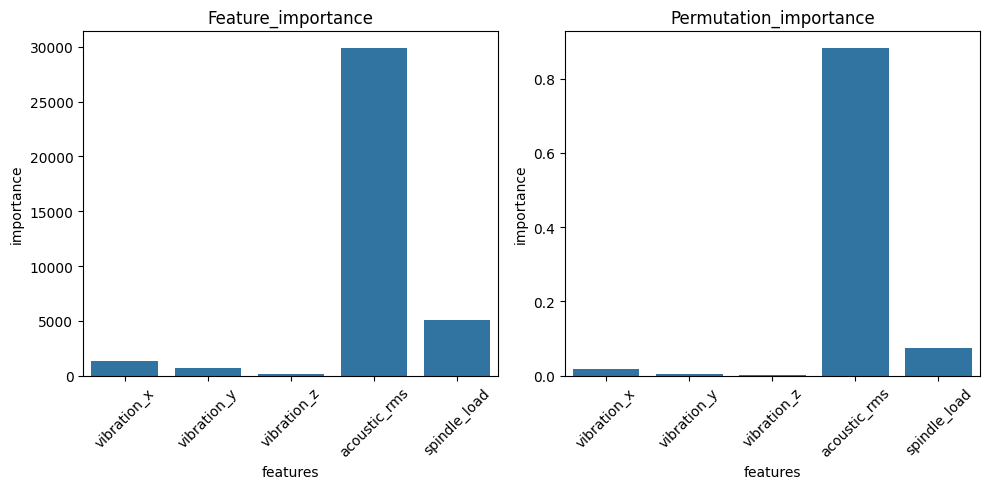

In [110]:
#各特徴量のモデル作成時の寄与を評価
feature_importance=pd.DataFrame(zip(X.columns, adjusted_model.feature_importance(importance_type='gain')), columns=['features', 'importance'])

#各特徴量のモデルの予測精度への寄与を評価
from sklearn.inspection import permutation_importance
regressor_model = lgb.LGBMRegressor()
regressor_model._Booster = adjusted_model
regressor_model._n_features = X_test.shape[1]
regressor_model.fitted_ = True
results = permutation_importance(regressor_model, X_test, y_test, n_repeats=10, random_state=42)
purmutation_importance=pd.DataFrame(zip(X.columns, results['importances'].mean(axis=1)), columns=['features', 'importance'])

#特徴量の重要性を表示
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.barplot(feature_importance, x='features', y='importance', errorbar=None)
plt.xticks(rotation=45)
plt.title('Feature_importance')
plt.tight_layout()

plt.subplot(1,2,2)
sns.barplot(purmutation_importance, x='features', y='importance', errorbar=None)
plt.xticks(rotation=45)
plt.title('Permutation_importance')
plt.tight_layout()

特徴量の重要度評価では、2つの指標はどちらも同じ傾向。"acoustic_rms"の寄与度が非常に大きく評価されていて、続いて"spindle_load", "vibration_x"となっている。これは、eda.ipynbで確認した各センサデータの"tool_wear"との相関係数の値とも矛盾しない。

次に、複数の加工データから移動平均を取ったデータセットでトライする。

In [111]:
#20行のデータの移動平均を使用したデータでトライ
path_avg20 = '../data/processed/mv_avg_20.csv'
df = pd.read_csv(path_avg20)

X = df.drop(["tool_wear"], axis=1)
y = df["tool_wear"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

avg20_model = model.get_best_booster()

[I 2025-11-03 15:27:43,700] A new study created in memory with name: no-name-2cd9fc07-dc75-44ec-903c-5740fa3b90e2
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000225 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.271400:  14%|8     | 1/7 [00:00<00:01,  3.27it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.271400:  29%|#7    | 2/7 [00:00<00:01,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.271400:  43%|##5   | 3/7 [00:00<00:01,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.271400:  57%|###4  | 4/7 [00:01<00:00,  3.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.271400:  71%|####2 | 5/7 [00:01<00:00,  3.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.271400:  86%|#####1| 6/7 [00:01<00:00,  3.29it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 0.271400:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.265909:   5%|5          | 1/20 [00:00<00:06,  2.76it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  10%|#1         | 2/20 [00:00<00:06,  2.76it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  20%|##2        | 4/20 [00:01<00:05,  2.77it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  25%|##7        | 5/20 [00:01<00:04,  3.60it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  30%|###3       | 6/20 [00:01<00:04,  3.31it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  35%|###8       | 7/20 [00:02<00:04,  3.13it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.265909:  40%|####4      | 8/20 [00:02<00:03,  3.00it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  45%|####9      | 9/20 [00:02<00:03,  2.92it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  50%|#####     | 10/20 [00:03<00:02,  3.51it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.265909:  55%|#####5    | 11/20 [00:03<00:02,  3.25it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  60%|######    | 12/20 [00:03<00:02,  3.08it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  65%|######5   | 13/20 [00:04<00:02,  2.97it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  70%|#######   | 14/20 [00:04<00:02,  2.90it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train s

num_leaves, val_score: 0.265909:  75%|#######5  | 15/20 [00:04<00:01,  2.85it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  80%|########  | 16/20 [00:05<00:01,  2.81it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  85%|########5 | 17/20 [00:05<00:01,  2.79it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  90%|######### | 18/20 [00:06<00:00,  2.79it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  95%|#########5| 19/20 [00:06<00:00,  2.78it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from s

num_leaves, val_score: 0.265909: 100%|##########| 20/20 [00:06<00:00,  2.96it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.265909:   0%|                      | 0/10 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

bagging, val_score: 0.265909:  10%|#4            | 1/10 [00:00<00:02,  4.41it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from s

bagging, val_score: 0.260224:  20%|##8           | 2/10 [00:00<00:02,  3.23it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.260224:  30%|####2         | 3/10 [00:00<00:02,  2.96it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.260224:  40%|#####6        | 4/10 [00:01<00:02,  2.87it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.260224:  50%|#######       | 5/10 [00:01<00:01,  2.83it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.260224:  60%|########4     | 6/10 [00:02<00:01,  2.80it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from s

bagging, val_score: 0.260224:  70%|#########7    | 7/10 [00:02<00:01,  2.77it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.260224:  80%|###########2  | 8/10 [00:02<00:00,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.260224:  90%|############6 | 9/10 [00:03<00:00,  2.80it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.260224: 100%|#############| 10/10 [00:03<00:00,  2.90it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f


feature_fraction_stage2, val_score: 0.260224:   0%|       | 0/3 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

feature_fraction_stage2, val_score: 0.260224:  33%|3| 1/3 [00:00<00:00,  2.73it/[I 2025-11-03 15:27:56,398] Trial 37 finished with value: 0.2602236490076882 and parameters: {'feature_fraction': 0.9520000000000001}. Best is trial 28 with value: 0.2602236490076882.
feature_fraction_stage2, val_score: 0.260224:  33%|3| 1/3 [00:00<00:00,  2.73it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

feature_fraction_stage2, val_score: 0.260224:  67%|6| 2/3 [00:00<00:00,  2.76it/[I 2025-11-03 15:27:56,758] Trial 38 finished with value: 0.2602236490076882 and parameters: {'feature_fraction': 0.9840000000000001}. Best is trial 28 with value: 0.2602236490076882.
feature_fraction_stage2, val_score: 0.260224:  67%|6| 2/3 [00:00<00:00,  2.76it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

feature_fraction_stage2, val_score: 0.260224: 100%|#| 3/3 [00:01<00:00,  2.77it/[I 2025-11-03 15:27:57,116] Trial 39 finished with value: 0.2602236490076882 and parameters: {'feature_fraction': 0.92}. Best is trial 28 with value: 0.2602236490076882.
feature_fraction_stage2, val_score: 0.260224: 100%|#| 3/3 [00:01<00:00,  2.77it/


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.260224:   0%|       | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.260224:   5%| | 1/20 [00:00<00:05,  3.21it/[I 2025-11-03 15:27:57,428] Trial 40 finished with value: 0.28544615753677455 and parameters: {'lambda_l1': 0.03370795140204577, 'lambda_l2': 5.22116123416323}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:   5%| | 1/20 [00:00<00:05,  3.21it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.260224:  10%|1| 2/20 [00:00<00:06,  2.92it/[I 2025-11-03 15:27:57,793] Trial 41 finished with value: 0.26022364906512724 and parameters: {'lambda_l1': 1.428012656474314e-08, 'lambda_l2': 1.5750664739976918e-08}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  10%|1| 2/20 [00:00<00:06,  2.92it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.260224:  15%|1| 3/20 [00:01<00:06,  2.82it/[I 2025-11-03 15:27:58,160] Trial 42 finished with value: 0.2602236491194325 and parameters: {'lambda_l1': 3.7941625584860096e-08, 'lambda_l2': 1.0314803026411407e-08}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  15%|1| 3/20 [00:01<00:06,  2.82it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from s

regularization_factors, val_score: 0.260224:  20%|2| 4/20 [00:01<00:05,  2.79it/[I 2025-11-03 15:27:58,527] Trial 43 finished with value: 0.2602236491396315 and parameters: {'lambda_l1': 1.1599503546042324e-08, 'lambda_l2': 6.941459489680188e-08}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  20%|2| 4/20 [00:01<00:05,  2.79it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.260224:  25%|2| 5/20 [00:01<00:05,  2.77it/[I 2025-11-03 15:27:58,892] Trial 44 finished with value: 0.2602237109068101 and parameters: {'lambda_l1': 1.3917623103997218e-05, 'lambda_l2': 0.00012155362640689564}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  25%|2| 5/20 [00:01<00:05,  2.77it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.260224:  30%|3| 6/20 [00:01<00:03,  3.54it/[I 2025-11-03 15:27:59,023] Trial 45 finished with value: 0.36015436538973655 and parameters: {'lambda_l1': 8.650131447021973, 'lambda_l2': 3.246937422027614e-05}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  30%|3| 6/20 [00:01<00:03,  3.54it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.260224:  35%|3| 7/20 [00:02<00:03,  3.26it/[I 2025-11-03 15:27:59,378] Trial 46 finished with value: 0.2717584191451106 and parameters: {'lambda_l1': 4.595878115848e-05, 'lambda_l2': 0.5348962248235467}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  35%|3| 7/20 [00:02<00:03,  3.26it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train s

regularization_factors, val_score: 0.260224:  40%|4| 8/20 [00:02<00:03,  3.07it/[I 2025-11-03 15:27:59,743] Trial 47 finished with value: 0.26022365181107265 and parameters: {'lambda_l1': 8.522857375497662e-07, 'lambda_l2': 1.5146628460228557e-06}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  40%|4| 8/20 [00:02<00:03,  3.07it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.260224:  45%|4| 9/20 [00:02<00:03,  2.98it/[I 2025-11-03 15:28:00,103] Trial 48 finished with value: 0.2665580657302696 and parameters: {'lambda_l1': 0.003325833007468076, 'lambda_l2': 0.020341265674585836}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  45%|4| 9/20 [00:02<00:03,  2.98it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.260224:  50%|5| 10/20 [00:03<00:03,  2.90it[I 2025-11-03 15:28:00,467] Trial 49 finished with value: 0.2615102176280426 and parameters: {'lambda_l1': 5.520889025959343e-07, 'lambda_l2': 0.0035887126218143387}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  50%|5| 10/20 [00:03<00:03,  2.90it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.260224:  55%|5| 11/20 [00:03<00:03,  2.87it[I 2025-11-03 15:28:00,823] Trial 50 finished with value: 0.2669273436164806 and parameters: {'lambda_l1': 0.1158036233657552, 'lambda_l2': 2.643386095798455e-06}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  55%|5| 11/20 [00:03<00:03,  2.87it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.260224:  60%|6| 12/20 [00:04<00:02,  2.83it[I 2025-11-03 15:28:01,188] Trial 51 finished with value: 0.2602236490961389 and parameters: {'lambda_l1': 1.7192847392089157e-08, 'lambda_l2': 1.3651148087013627e-08}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  60%|6| 12/20 [00:04<00:02,  2.83it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.260224:  65%|6| 13/20 [00:04<00:02,  2.80it[I 2025-11-03 15:28:01,555] Trial 52 finished with value: 0.2602236505733131 and parameters: {'lambda_l1': 4.635216609901675e-07, 'lambda_l2': 2.841196155807327e-07}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  65%|6| 13/20 [00:04<00:02,  2.80it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-ch

regularization_factors, val_score: 0.260224:  70%|7| 14/20 [00:04<00:02,  2.78it[I 2025-11-03 15:28:01,919] Trial 53 finished with value: 0.2602236491016807 and parameters: {'lambda_l1': 1.409333553102343e-08, 'lambda_l2': 2.1351062763811345e-08}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  70%|7| 14/20 [00:04<00:02,  2.78it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.260224:  75%|7| 15/20 [00:05<00:01,  2.77it[I 2025-11-03 15:28:02,283] Trial 54 finished with value: 0.26022367061250024 and parameters: {'lambda_l1': 7.97508516101704e-06, 'lambda_l2': 9.48816330388111e-06}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  75%|7| 15/20 [00:05<00:01,  2.77it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.260224:  80%|8| 16/20 [00:05<00:01,  2.76it[I 2025-11-03 15:28:02,648] Trial 55 finished with value: 0.26104550374848706 and parameters: {'lambda_l1': 0.0007282524736264736, 'lambda_l2': 1.9268588301859058e-07}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  80%|8| 16/20 [00:05<00:01,  2.76it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.260224:  85%|8| 17/20 [00:05<00:01,  2.76it[I 2025-11-03 15:28:03,012] Trial 56 finished with value: 0.26022384533729004 and parameters: {'lambda_l1': 1.2528513181722183e-07, 'lambda_l2': 0.0008418421457103358}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  85%|8| 17/20 [00:05<00:01,  2.76it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.260224:  90%|9| 18/20 [00:06<00:00,  2.75it[I 2025-11-03 15:28:03,377] Trial 57 finished with value: 0.26022365307222467 and parameters: {'lambda_l1': 1.4735749460749367e-06, 'lambda_l2': 7.576840589794449e-07}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  90%|9| 18/20 [00:06<00:00,  2.75it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 secon

regularization_factors, val_score: 0.260224:  95%|9| 19/20 [00:06<00:00,  2.75it[I 2025-11-03 15:28:03,742] Trial 58 finished with value: 0.26022392915187104 and parameters: {'lambda_l1': 0.0001168341686784612, 'lambda_l2': 1.2187873903172387e-08}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224:  95%|9| 19/20 [00:06<00:00,  2.75it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.260224: 100%|#| 20/20 [00:06<00:00,  2.76it[I 2025-11-03 15:28:04,103] Trial 59 finished with value: 0.26022365298078765 and parameters: {'lambda_l1': 9.305993305088526e-08, 'lambda_l2': 1.4272651968238072e-05}. Best is trial 28 with value: 0.2602236490076882.
regularization_factors, val_score: 0.260224: 100%|#| 20/20 [00:06<00:00,  2.86it


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

min_child_samples, val_score: 0.260224:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

min_child_samples, val_score: 0.260224:  20%|#    | 1/5 [00:00<00:00,  6.25it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

min_child_samples, val_score: 0.260224:  40%|##   | 2/5 [00:00<00:00,  6.25it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 0.241783:  60%|###  | 3/5 [00:00<00:00,  3.43it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 0.241783:  80%|#### | 4/5 [00:01<00:00,  2.59it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

min_child_samples, val_score: 0.241783: 100%|#####| 5/5 [00:01<00:00,  2.96it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [112]:
train_predict = avg20_model.predict(X_train)
test_predict = avg20_model.predict(X_test)
MAE_train  =mean_absolute_error(y_train, train_predict)
MAE_test  =mean_absolute_error(y_test, test_predict)
R2_train = r2_score(y_train, train_predict)
R2_test = r2_score(y_test, test_predict)
result = {
    "model":"LightGBM",
    "dataset":"mv_avg_20",
    "MAE_train":mean_absolute_error(y_train, train_predict),
    "MAE_test":mean_absolute_error(y_test, test_predict),
    "R^2_train":r2_score(y_train, train_predict),
    "R^2_test":r2_score(y_test, test_predict)
}

pprint(result)
result_list.append(result)

{'MAE_test': 0.24178317858449985,
 'MAE_train': 0.02962529868827038,
 'R^2_test': 0.9906742912661607,
 'R^2_train': 0.9998863740382539,
 'dataset': 'mv_avg_20',
 'model': 'LightGBM'}


In [113]:
#10行のデータの移動平均を使用したデータでトライ
path_avg10 = '../data/processed/mv_avg_10.csv'
df = pd.read_csv(path_avg10)

X = df.drop(["tool_wear"], axis=1)
y = df["tool_wear"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

avg10_model = model.get_best_booster()

[I 2025-11-03 15:28:08,419] A new study created in memory with name: no-name-af23d604-6b5c-418f-9731-73927de0bba4
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000147 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.576977:  14%|8     | 1/7 [00:00<00:01,  3.26it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.576977:  29%|#7    | 2/7 [00:00<00:01,  3.29it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.576977:  43%|##5   | 3/7 [00:00<00:01,  3.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.576977:  57%|###4  | 4/7 [00:01<00:00,  3.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.576977:  71%|####2 | 5/7 [00:01<00:00,  3.31it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.576977:  86%|#####1| 6/7 [00:01<00:00,  3.31it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 0.576977:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.576977:   5%|5          | 1/20 [00:00<00:06,  2.81it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  10%|#1         | 2/20 [00:00<00:06,  2.81it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  15%|#6         | 3/20 [00:01<00:06,  2.82it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  20%|##2        | 4/20 [00:01<00:05,  2.80it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.576977:  25%|##7        | 5/20 [00:01<00:05,  2.79it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  35%|###8       | 7/20 [00:02<00:04,  2.80it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  40%|####4      | 8/20 [00:02<00:03,  3.50it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  45%|####9      | 9/20 [00:02<00:03,  3.29it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  50%|#####     | 10/20 [00:03<00:03,  3.14it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 secon

num_leaves, val_score: 0.576977:  55%|#####5    | 11/20 [00:03<00:02,  3.05it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  60%|######    | 12/20 [00:03<00:02,  2.98it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  65%|######5   | 13/20 [00:04<00:02,  2.93it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  75%|#######5  | 15/20 [00:04<00:01,  2.90it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 secon

num_leaves, val_score: 0.576977:  80%|########  | 16/20 [00:05<00:01,  3.58it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

num_leaves, val_score: 0.576977:  85%|########5 | 17/20 [00:05<00:00,  3.36it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  90%|######### | 18/20 [00:05<00:00,  3.20it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  95%|#########5| 19/20 [00:06<00:00,  3.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.576977:   0%|                      | 0/10 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

bagging, val_score: 0.576977:  10%|#4            | 1/10 [00:00<00:01,  4.63it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.576977:  20%|##8           | 2/10 [00:00<00:02,  3.24it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.576977:  30%|####2         | 3/10 [00:00<00:02,  3.22it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.576977:  40%|#####6        | 4/10 [00:01<00:01,  3.22it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.576977:  50%|#######       | 5/10 [00:01<00:01,  3.20it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

bagging, val_score: 0.576977:  60%|########4     | 6/10 [00:01<00:01,  3.25it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 secon

bagging, val_score: 0.576977:  70%|#########7    | 7/10 [00:02<00:00,  3.32it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.576977:  80%|###########2  | 8/10 [00:02<00:00,  3.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

bagging, val_score: 0.576977: 100%|#############| 10/10 [00:02<00:00,  4.05it/s][I 2025-11-03 15:28:19,680] Trial 36 finished with value: 0.6313481525389263 and parameters: {'bagging_fraction': 0.44409704862812904, 'bagging_freq': 1}. Best is trial 0 with value: 0.5769768184781733.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 secon

feature_fraction_stage2, val_score: 0.576977:   0%|       | 0/3 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.576977:  33%|3| 1/3 [00:00<00:00,  3.26it/[I 2025-11-03 15:28:19,988] Trial 37 finished with value: 0.5769768184781733 and parameters: {'feature_fraction': 0.9520000000000001}. Best is trial 0 with value: 0.5769768184781733.
feature_fraction_stage2, val_score: 0.576977:  33%|3| 1/3 [00:00<00:00,  3.26it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.576977:  67%|6| 2/3 [00:00<00:00,  3.27it/[I 2025-11-03 15:28:20,293] Trial 38 finished with value: 0.5769768184781733 and parameters: {'feature_fraction': 0.9840000000000001}. Best is trial 0 with value: 0.5769768184781733.
feature_fraction_stage2, val_score: 0.576977:  67%|6| 2/3 [00:00<00:00,  3.27it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.576977: 100%|#| 3/3 [00:00<00:00,  3.27it/[I 2025-11-03 15:28:20,599] Trial 39 finished with value: 0.5769768184781733 and parameters: {'feature_fraction': 0.92}. Best is trial 0 with value: 0.5769768184781733.
feature_fraction_stage2, val_score: 0.576977: 100%|#| 3/3 [00:00<00:00,  3.27it/
regularization_factors, val_score: 0.576977:   0%|       | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:   5%| | 1/20 [00:00<00:05,  3.26it/[I 2025-11-03 15:28:20,908] Trial 40 finished with value: 0.5815995376515342 and parameters: {'lambda_l1': 0.014235597620892304, 'lambda_l2': 9.760006873602742e-06}. Best is trial 0 with value: 0.5769768184781733.
regularization_factors, val_score: 0.576977:   5%| | 1/20 [00:00<00:05,  3.26it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.576977:  10%|1| 2/20 [00:00<00:05,  3.41it/[I 2025-11-03 15:28:21,191] Trial 41 finished with value: 0.6040536604612359 and parameters: {'lambda_l1': 3.34162844029285e-08, 'lambda_l2': 5.96782718608156}. Best is trial 0 with value: 0.5769768184781733.
regularization_factors, val_score: 0.576977:  10%|1| 2/20 [00:00<00:05,  3.41it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.576977:  15%|1| 3/20 [00:00<00:04,  3.48it/[I 2025-11-03 15:28:21,471] Trial 42 finished with value: 0.5992317289853736 and parameters: {'lambda_l1': 1.9379135874632443, 'lambda_l2': 1.6886141336596065e-08}. Best is trial 0 with value: 0.5769768184781733.
regularization_factors, val_score: 0.576977:  15%|1| 3/20 [00:00<00:04,  3.48it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.576977:  20%|2| 4/20 [00:01<00:04,  3.44it/[I 2025-11-03 15:28:21,768] Trial 43 finished with value: 0.5881383016512834 and parameters: {'lambda_l1': 8.708679685964081e-08, 'lambda_l2': 1.5169144400308796}. Best is trial 0 with value: 0.5769768184781733.
regularization_factors, val_score: 0.576977:  20%|2| 4/20 [00:01<00:04,  3.44it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576974:  25%|2| 5/20 [00:01<00:04,  3.36it/[I 2025-11-03 15:28:22,077] Trial 44 finished with value: 0.5769744102008784 and parameters: {'lambda_l1': 7.06101450045093e-05, 'lambda_l2': 0.001391109934004235}. Best is trial 44 with value: 0.5769744102008784.
regularization_factors, val_score: 0.576974:  25%|2| 5/20 [00:01<00:04,  3.36it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576974:  30%|3| 6/20 [00:01<00:04,  3.32it/[I 2025-11-03 15:28:22,385] Trial 45 finished with value: 0.5769744707620805 and parameters: {'lambda_l1': 2.8657848105860897e-05, 'lambda_l2': 0.001347675360194191}. Best is trial 44 with value: 0.5769744102008784.
regularization_factors, val_score: 0.576974:  30%|3| 6/20 [00:01<00:04,  3.32it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576973:  35%|3| 7/20 [00:02<00:03,  3.29it/[I 2025-11-03 15:28:22,694] Trial 46 finished with value: 0.5769734433196211 and parameters: {'lambda_l1': 5.438825905739732e-05, 'lambda_l2': 0.001940274569788327}. Best is trial 46 with value: 0.5769734433196211.
regularization_factors, val_score: 0.576973:  35%|3| 7/20 [00:02<00:03,  3.29it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576973:  40%|4| 8/20 [00:02<00:03,  3.27it/[I 2025-11-03 15:28:23,003] Trial 47 finished with value: 0.5769733996607123 and parameters: {'lambda_l1': 9.167963373922978e-05, 'lambda_l2': 0.001973086247238481}. Best is trial 47 with value: 0.5769733996607123.
regularization_factors, val_score: 0.576973:  40%|4| 8/20 [00:02<00:03,  3.27it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576973:  45%|4| 9/20 [00:02<00:03,  3.27it/[I 2025-11-03 15:28:23,309] Trial 48 finished with value: 0.5769742614304689 and parameters: {'lambda_l1': 5.517718573513654e-05, 'lambda_l2': 0.0014727940847440375}. Best is trial 47 with value: 0.5769733996607123.
regularization_factors, val_score: 0.576973:  45%|4| 9/20 [00:02<00:03,  3.27it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576973:  50%|5| 10/20 [00:03<00:03,  3.27it[I 2025-11-03 15:28:23,616] Trial 49 finished with value: 0.5769742277039414 and parameters: {'lambda_l1': 4.926302994024944e-05, 'lambda_l2': 0.0014912239810000814}. Best is trial 47 with value: 0.5769733996607123.
regularization_factors, val_score: 0.576973:  50%|5| 10/20 [00:03<00:03,  3.27it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576973:  55%|5| 11/20 [00:03<00:02,  3.26it[I 2025-11-03 15:28:23,923] Trial 50 finished with value: 0.5769752023457182 and parameters: {'lambda_l1': 5.1066698254273854e-05, 'lambda_l2': 0.0009342191598260184}. Best is trial 47 with value: 0.5769733996607123.
regularization_factors, val_score: 0.576973:  55%|5| 11/20 [00:03<00:02,  3.26it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576973:  60%|6| 12/20 [00:03<00:02,  3.26it[I 2025-11-03 15:28:24,229] Trial 51 finished with value: 0.5769730250665998 and parameters: {'lambda_l1': 3.82122627687049e-05, 'lambda_l2': 0.002176279488494726}. Best is trial 51 with value: 0.5769730250665998.
regularization_factors, val_score: 0.576973:  60%|6| 12/20 [00:03<00:02,  3.26it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576972:  65%|6| 13/20 [00:03<00:02,  3.28it[I 2025-11-03 15:28:24,532] Trial 52 finished with value: 0.5769723218520091 and parameters: {'lambda_l1': 5.517351861601304e-05, 'lambda_l2': 0.00258190608355302}. Best is trial 52 with value: 0.5769723218520091.
regularization_factors, val_score: 0.576972:  65%|6| 13/20 [00:03<00:02,  3.28it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576972:  70%|7| 14/20 [00:04<00:01,  3.27it[I 2025-11-03 15:28:24,838] Trial 53 finished with value: 0.5930174385579692 and parameters: {'lambda_l1': 2.1168845529332155e-05, 'lambda_l2': 0.006391307263678262}. Best is trial 52 with value: 0.5769723218520091.
regularization_factors, val_score: 0.576972:  70%|7| 14/20 [00:04<00:01,  3.27it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576972:  75%|7| 15/20 [00:04<00:01,  3.27it[I 2025-11-03 15:28:25,145] Trial 54 finished with value: 0.5931245115218629 and parameters: {'lambda_l1': 0.0003705276229863023, 'lambda_l2': 0.013653735226211293}. Best is trial 52 with value: 0.5769723218520091.
regularization_factors, val_score: 0.576972:  75%|7| 15/20 [00:04<00:01,  3.27it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576972:  80%|8| 16/20 [00:04<00:01,  3.27it[I 2025-11-03 15:28:25,452] Trial 55 finished with value: 0.5769767867750267 and parameters: {'lambda_l1': 0.00032347579079121093, 'lambda_l2': 8.470335258905805e-05}. Best is trial 52 with value: 0.5769723218520091.
regularization_factors, val_score: 0.576972:  80%|8| 16/20 [00:04<00:01,  3.27it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576972:  85%|8| 17/20 [00:05<00:00,  3.27it[I 2025-11-03 15:28:25,757] Trial 56 finished with value: 0.5849103168794995 and parameters: {'lambda_l1': 3.9997044817558546e-06, 'lambda_l2': 0.008687530174529156}. Best is trial 52 with value: 0.5769723218520091.
regularization_factors, val_score: 0.576972:  85%|8| 17/20 [00:05<00:00,  3.27it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576972:  90%|9| 18/20 [00:05<00:00,  3.27it[I 2025-11-03 15:28:26,064] Trial 57 finished with value: 0.5769765672490251 and parameters: {'lambda_l1': 1.5951041803379404e-06, 'lambda_l2': 0.00014430579525898996}. Best is trial 52 with value: 0.5769723218520091.
regularization_factors, val_score: 0.576972:  90%|9| 18/20 [00:05<00:00,  3.27it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576972:  95%|9| 19/20 [00:05<00:00,  3.26it[I 2025-11-03 15:28:26,370] Trial 58 finished with value: 0.5828023966348466 and parameters: {'lambda_l1': 0.0012482761248541435, 'lambda_l2': 0.04850790416546098}. Best is trial 52 with value: 0.5769723218520091.
regularization_factors, val_score: 0.576972:  95%|9| 19/20 [00:05<00:00,  3.26it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000118 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576972: 100%|#| 20/20 [00:06<00:00,  3.27it[I 2025-11-03 15:28:26,674] Trial 59 finished with value: 0.5769764090654075 and parameters: {'lambda_l1': 4.284686296200609e-06, 'lambda_l2': 0.0002345596990913266}. Best is trial 52 with value: 0.5769723218520091.
regularization_factors, val_score: 0.576972: 100%|#| 20/20 [00:06<00:00,  3.29it
min_child_samples, val_score: 0.576972:  20%|#    | 1/5 [00:00<00:00,  6.60it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

min_child_samples, val_score: 0.576972:  40%|##   | 2/5 [00:00<00:00,  6.60it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

min_child_samples, val_score: 0.558596:  60%|###  | 3/5 [00:00<00:00,  5.48it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 0.558596:  80%|#### | 4/5 [00:00<00:00,  4.45it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

min_child_samples, val_score: 0.558596: 100%|#####| 5/5 [00:01<00:00,  4.42it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 31, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_freq': 0, 'bagging_fraction': 1.0, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 5.517351861601304e-05, 'lambda_l2': 0.00258190608355302, 'min_child_samples': 5}


In [114]:
train_predict = avg10_model.predict(X_train)
test_predict = avg10_model.predict(X_test)
MAE_train  =mean_absolute_error(y_train, train_predict)
MAE_test  =mean_absolute_error(y_test, test_predict)
R2_train = r2_score(y_train, train_predict)
R2_test = r2_score(y_test, test_predict)
result = {
    "model":"LightGBM",
    "dataset":"mv_avg_10",
    "MAE_train":mean_absolute_error(y_train, train_predict),
    "MAE_test":mean_absolute_error(y_test, test_predict),
    "R^2_train":r2_score(y_train, train_predict),
    "R^2_test":r2_score(y_test, test_predict)
}

pprint(result)
result_list.append(result)

{'MAE_test': 0.5585958121858127,
 'MAE_train': 0.1503464445550693,
 'R^2_test': 0.9616928574615881,
 'R^2_train': 0.997595103645927,
 'dataset': 'mv_avg_10',
 'model': 'LightGBM'}


In [115]:
#5行のデータの移動平均を使用したデータでトライ
path_avg5 = '../data/processed/mv_avg_5.csv'
df = pd.read_csv(path_avg5)

X = df.drop(["tool_wear"], axis=1)
y = df["tool_wear"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

avg5_model = model.get_best_booster()

[I 2025-11-03 15:28:31,565] A new study created in memory with name: no-name-edf73966-e4cf-4333-9709-73408c6e4a6f
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000156 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.922167:  14%|8     | 1/7 [00:00<00:01,  3.19it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.922167:  29%|#7    | 2/7 [00:00<00:01,  3.25it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.922167:  43%|##5   | 3/7 [00:00<00:01,  3.27it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.917595:  57%|###4  | 4/7 [00:01<00:00,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.917595:  71%|####2 | 5/7 [00:01<00:00,  3.29it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.917595:  86%|#####1| 6/7 [00:01<00:00,  3.29it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 0.917595:   5%|5          | 1/20 [00:00<00:02,  6.85it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 0.917595:  10%|#1         | 2/20 [00:00<00:03,  4.51it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.917595:  15%|#6         | 3/20 [00:00<00:04,  3.55it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.917595:  20%|##2        | 4/20 [00:01<00:04,  3.21it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.917595:  25%|##7        | 5/20 [00:01<00:04,  3.07it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.917595:  30%|###3       | 6/20 [00:01<00:04,  2.97it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.917595:  35%|###8       | 7/20 [00:02<00:04,  2.92it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.917595:  40%|####4      | 8/20 [00:02<00:04,  2.88it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.917595:  45%|####9      | 9/20 [00:02<00:03,  2.87it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.917595:  50%|#####     | 10/20 [00:03<00:03,  2.86it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.917595:  55%|#####5    | 11/20 [00:03<00:03,  2.85it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.917595:  60%|######    | 12/20 [00:03<00:02,  2.84it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.917595:  65%|######5   | 13/20 [00:04<00:02,  2.83it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.917595:  75%|#######5  | 15/20 [00:04<00:01,  2.82it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 0.917595:  85%|########5 | 17/20 [00:05<00:00,  3.77it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

num_leaves, val_score: 0.917595:  90%|######### | 18/20 [00:05<00:00,  4.21it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.917595:  95%|#########5| 19/20 [00:05<00:00,  3.84it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.917595: 100%|##########| 20/20 [00:06<00:00,  3.29it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.917595:   0%|                      | 0/10 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

bagging, val_score: 0.917595:  10%|#4            | 1/10 [00:00<00:01,  5.81it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.917595:  20%|##8           | 2/10 [00:00<00:02,  3.99it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

bagging, val_score: 0.917595:  30%|####2         | 3/10 [00:00<00:01,  3.79it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.917595:  40%|#####6        | 4/10 [00:00<00:01,  4.51it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.917595:  50%|#######       | 5/10 [00:01<00:01,  4.38it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.917595:  60%|########4     | 6/10 [00:01<00:01,  3.91it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

bagging, val_score: 0.917595:  70%|#########7    | 7/10 [00:01<00:00,  3.92it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.917595:  80%|###########2  | 8/10 [00:01<00:00,  4.18it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.917595:  90%|############6 | 9/10 [00:02<00:00,  3.88it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train s

bagging, val_score: 0.917595: 100%|#############| 10/10 [00:02<00:00,  4.11it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

feature_fraction_stage2, val_score: 0.917595:   0%|       | 0/6 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.917595:  17%|1| 1/6 [00:00<00:01,  3.32it/[I 2025-11-03 15:28:42,517] Trial 37 finished with value: 0.9175949768189862 and parameters: {'feature_fraction': 0.748}. Best is trial 3 with value: 0.9175949768189862.
feature_fraction_stage2, val_score: 0.917595:  17%|1| 1/6 [00:00<00:01,  3.32it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.917595:  33%|3| 2/6 [00:00<00:01,  3.31it/[I 2025-11-03 15:28:42,820] Trial 38 finished with value: 0.9242595546966985 and parameters: {'feature_fraction': 0.652}. Best is trial 3 with value: 0.9175949768189862.
feature_fraction_stage2, val_score: 0.917595:  33%|3| 2/6 [00:00<00:01,  3.31it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.917595:  50%|5| 3/6 [00:00<00:00,  3.30it/[I 2025-11-03 15:28:43,125] Trial 39 finished with value: 0.9175949768189862 and parameters: {'feature_fraction': 0.7799999999999999}. Best is trial 3 with value: 0.9175949768189862.
feature_fraction_stage2, val_score: 0.917595:  50%|5| 3/6 [00:00<00:00,  3.30it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.917595:  67%|6| 4/6 [00:01<00:00,  3.30it/[I 2025-11-03 15:28:43,428] Trial 40 finished with value: 0.9242595546966985 and parameters: {'feature_fraction': 0.62}. Best is trial 3 with value: 0.9175949768189862.
feature_fraction_stage2, val_score: 0.917595:  67%|6| 4/6 [00:01<00:00,  3.30it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.917595:  83%|8| 5/6 [00:01<00:00,  3.30it/[I 2025-11-03 15:28:43,730] Trial 41 finished with value: 0.9242595546966985 and parameters: {'feature_fraction': 0.6839999999999999}. Best is trial 3 with value: 0.9175949768189862.
feature_fraction_stage2, val_score: 0.917595:  83%|8| 5/6 [00:01<00:00,  3.30it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.917595: 100%|#| 6/6 [00:01<00:00,  3.29it/[I 2025-11-03 15:28:44,035] Trial 42 finished with value: 0.9175949768189862 and parameters: {'feature_fraction': 0.716}. Best is trial 3 with value: 0.9175949768189862.
feature_fraction_stage2, val_score: 0.917595: 100%|#| 6/6 [00:01<00:00,  3.30it/
regularization_factors, val_score: 0.917595:   0%|       | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.917595:   5%| | 1/20 [00:00<00:05,  3.49it/[I 2025-11-03 15:28:44,323] Trial 43 finished with value: 0.9426711587711025 and parameters: {'lambda_l1': 1.44534720038641, 'lambda_l2': 1.886270885593477}. Best is trial 3 with value: 0.9175949768189862.
regularization_factors, val_score: 0.917595:   5%| | 1/20 [00:00<00:05,  3.49it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  10%|1| 2/20 [00:00<00:05,  3.39it/[I 2025-11-03 15:28:44,625] Trial 44 finished with value: 0.9175949765814372 and parameters: {'lambda_l1': 7.273676504896566e-08, 'lambda_l2': 1.1214048236193206e-08}. Best is trial 44 with value: 0.9175949765814372.
regularization_factors, val_score: 0.917595:  10%|1| 2/20 [00:00<00:05,  3.39it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  15%|1| 3/20 [00:00<00:05,  3.33it/[I 2025-11-03 15:28:44,931] Trial 45 finished with value: 0.917594976761832 and parameters: {'lambda_l1': 1.0146630704260494e-08, 'lambda_l2': 1.7084722727129893e-08}. Best is trial 44 with value: 0.9175949765814372.
regularization_factors, val_score: 0.917595:  15%|1| 3/20 [00:00<00:05,  3.33it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  20%|2| 4/20 [00:01<00:04,  3.30it/[I 2025-11-03 15:28:45,237] Trial 46 finished with value: 0.917594976772278 and parameters: {'lambda_l1': 1.4323373401396989e-08, 'lambda_l2': 1.618792057447271e-08}. Best is trial 44 with value: 0.9175949765814372.
regularization_factors, val_score: 0.917595:  20%|2| 4/20 [00:01<00:04,  3.30it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  25%|2| 5/20 [00:01<00:04,  3.29it/[I 2025-11-03 15:28:45,543] Trial 47 finished with value: 0.9175949767356821 and parameters: {'lambda_l1': 1.6334031512055076e-08, 'lambda_l2': 1.1319360356470402e-08}. Best is trial 44 with value: 0.9175949765814372.
regularization_factors, val_score: 0.917595:  25%|2| 5/20 [00:01<00:04,  3.29it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  30%|3| 6/20 [00:01<00:04,  3.28it/[I 2025-11-03 15:28:45,849] Trial 48 finished with value: 0.9175949767170413 and parameters: {'lambda_l1': 2.0500893473297846e-08, 'lambda_l2': 1.1496152364603615e-08}. Best is trial 44 with value: 0.9175949765814372.
regularization_factors, val_score: 0.917595:  30%|3| 6/20 [00:01<00:04,  3.28it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  35%|3| 7/20 [00:02<00:03,  3.31it/[I 2025-11-03 15:28:46,147] Trial 49 finished with value: 0.9175949767766525 and parameters: {'lambda_l1': 1.1916492901432332e-08, 'lambda_l2': 1.1435980636391981e-08}. Best is trial 44 with value: 0.9175949765814372.
regularization_factors, val_score: 0.917595:  35%|3| 7/20 [00:02<00:03,  3.31it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  40%|4| 8/20 [00:02<00:03,  3.30it/[I 2025-11-03 15:28:46,452] Trial 50 finished with value: 0.9175949767668324 and parameters: {'lambda_l1': 1.1906666509421537e-08, 'lambda_l2': 1.1984153316440737e-08}. Best is trial 44 with value: 0.9175949765814372.
regularization_factors, val_score: 0.917595:  40%|4| 8/20 [00:02<00:03,  3.30it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  45%|4| 9/20 [00:02<00:03,  3.29it/[I 2025-11-03 15:28:46,758] Trial 51 finished with value: 0.9175949767800033 and parameters: {'lambda_l1': 1.252957987132238e-08, 'lambda_l2': 1.323574566539489e-08}. Best is trial 44 with value: 0.9175949765814372.
regularization_factors, val_score: 0.917595:  45%|4| 9/20 [00:02<00:03,  3.29it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  50%|5| 10/20 [00:03<00:03,  3.30it[I 2025-11-03 15:28:47,058] Trial 52 finished with value: 0.9175949767927493 and parameters: {'lambda_l1': 1.3801173784107992e-08, 'lambda_l2': 2.5374340338311817e-08}. Best is trial 44 with value: 0.9175949765814372.
regularization_factors, val_score: 0.917595:  50%|5| 10/20 [00:03<00:03,  3.30it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  55%|5| 11/20 [00:03<00:02,  3.30it[I 2025-11-03 15:28:47,361] Trial 53 finished with value: 0.9175949767422099 and parameters: {'lambda_l1': 1.5024833185385347e-08, 'lambda_l2': 1.0524610547605609e-08}. Best is trial 44 with value: 0.9175949765814372.
regularization_factors, val_score: 0.917595:  55%|5| 11/20 [00:03<00:02,  3.30it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  60%|6| 12/20 [00:03<00:02,  3.33it[I 2025-11-03 15:28:47,657] Trial 54 finished with value: 0.917594976784078 and parameters: {'lambda_l1': 1.736166490549532e-08, 'lambda_l2': 1.028876723471863e-08}. Best is trial 44 with value: 0.9175949765814372.
regularization_factors, val_score: 0.917595:  60%|6| 12/20 [00:03<00:02,  3.33it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  65%|6| 13/20 [00:03<00:02,  3.33it[I 2025-11-03 15:28:47,955] Trial 55 finished with value: 0.9175949762565857 and parameters: {'lambda_l1': 1.1398592927869906e-07, 'lambda_l2': 1.0038318705160662e-08}. Best is trial 55 with value: 0.9175949762565857.
regularization_factors, val_score: 0.917595:  65%|6| 13/20 [00:03<00:02,  3.33it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  70%|7| 14/20 [00:04<00:01,  3.33it[I 2025-11-03 15:28:48,257] Trial 56 finished with value: 0.9175949713551926 and parameters: {'lambda_l1': 9.917439659415344e-07, 'lambda_l2': 1.1057477961104787e-06}. Best is trial 56 with value: 0.9175949713551926.
regularization_factors, val_score: 0.917595:  70%|7| 14/20 [00:04<00:01,  3.33it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  75%|7| 15/20 [00:04<00:01,  3.31it[I 2025-11-03 15:28:48,564] Trial 57 finished with value: 0.917594954505785 and parameters: {'lambda_l1': 3.883282427263681e-06, 'lambda_l2': 6.928868153524533e-06}. Best is trial 57 with value: 0.917594954505785.
regularization_factors, val_score: 0.917595:  75%|7| 15/20 [00:04<00:01,  3.31it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  80%|8| 16/20 [00:04<00:01,  3.30it[I 2025-11-03 15:28:48,869] Trial 58 finished with value: 0.9175949599108136 and parameters: {'lambda_l1': 3.1674219984751435e-06, 'lambda_l2': 3.3286088419079414e-06}. Best is trial 57 with value: 0.917594954505785.
regularization_factors, val_score: 0.917595:  80%|8| 16/20 [00:04<00:01,  3.30it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  85%|8| 17/20 [00:05<00:00,  3.29it[I 2025-11-03 15:28:49,175] Trial 59 finished with value: 0.9175949445115555 and parameters: {'lambda_l1': 6.467005211544697e-06, 'lambda_l2': 3.612657574437623e-06}. Best is trial 59 with value: 0.9175949445115555.
regularization_factors, val_score: 0.917595:  85%|8| 17/20 [00:05<00:00,  3.29it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  90%|9| 18/20 [00:05<00:00,  3.29it[I 2025-11-03 15:28:49,480] Trial 60 finished with value: 0.9175949568285992 and parameters: {'lambda_l1': 3.4471454430429465e-06, 'lambda_l2': 6.0850262948453635e-06}. Best is trial 59 with value: 0.9175949445115555.
regularization_factors, val_score: 0.917595:  90%|9| 18/20 [00:05<00:00,  3.29it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595:  95%|9| 19/20 [00:05<00:00,  3.28it[I 2025-11-03 15:28:49,785] Trial 61 finished with value: 0.9175949568185592 and parameters: {'lambda_l1': 3.618278120737055e-06, 'lambda_l2': 5.060715828108982e-06}. Best is trial 59 with value: 0.9175949445115555.
regularization_factors, val_score: 0.917595:  95%|9| 19/20 [00:05<00:00,  3.28it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.917595: 100%|#| 20/20 [00:06<00:00,  3.28it[I 2025-11-03 15:28:50,090] Trial 62 finished with value: 0.9175949560564167 and parameters: {'lambda_l1': 3.7752168656128812e-06, 'lambda_l2': 4.749093598820428e-06}. Best is trial 59 with value: 0.9175949445115555.
regularization_factors, val_score: 0.917595: 100%|#| 20/20 [00:06<00:00,  3.30it
min_child_samples, val_score: 0.917595:  20%|#    | 1/5 [00:00<00:00,  6.57it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

min_child_samples, val_score: 0.917595:  40%|##   | 2/5 [00:00<00:00,  6.57it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

min_child_samples, val_score: 0.917595:  60%|###  | 3/5 [00:00<00:00,  5.38it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 0.917595:  80%|#### | 4/5 [00:00<00:00,  4.36it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

min_child_samples, val_score: 0.917595: 100%|#####| 5/5 [00:01<00:00,  4.36it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [116]:
train_predict = avg5_model.predict(X_train)
test_predict = avg5_model.predict(X_test)
MAE_train  =mean_absolute_error(y_train, train_predict)
MAE_test  =mean_absolute_error(y_test, test_predict)
R2_train = r2_score(y_train, train_predict)
R2_test = r2_score(y_test, test_predict)
result = {
    "model":"LightGBM",
    "dataset":"mv_avg_5",
    "MAE_train":mean_absolute_error(y_train, train_predict),
    "MAE_test":mean_absolute_error(y_test, test_predict),
    "R^2_train":r2_score(y_train, train_predict),
    "R^2_test":r2_score(y_test, test_predict)
}

pprint(result)
result_list.append(result)

{'MAE_test': 0.9175949482340245,
 'MAE_train': 0.39179910088523534,
 'R^2_test': 0.907897347387937,
 'R^2_train': 0.9850962176865522,
 'dataset': 'mv_avg_5',
 'model': 'LightGBM'}


In [117]:
#2行のデータの移動平均を使用したデータでトライ
path_avg2 = '../data/processed/mv_avg_2.csv'
df = pd.read_csv(path_avg2)

X = df.drop(["tool_wear"], axis=1)
y = df["tool_wear"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

avg2_model = model.get_best_booster()

[I 2025-11-03 15:28:54,843] A new study created in memory with name: no-name-e84c8bd2-a074-4cd7-9385-dc7065653e15
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000173 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.581950:  14%|8     | 1/7 [00:00<00:01,  3.22it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.581950:  29%|#7    | 2/7 [00:00<00:01,  3.27it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.581950:  43%|##5   | 3/7 [00:00<00:01,  3.29it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.581950:  57%|###4  | 4/7 [00:01<00:00,  3.33it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.581950:  71%|####2 | 5/7 [00:01<00:00,  3.34it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.581950:  86%|#####1| 6/7 [00:01<00:00,  3.33it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.581950:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


num_leaves, val_score: 1.564442:   5%|5          | 1/20 [00:00<00:06,  3.16it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.560185:  10%|#1         | 2/20 [00:00<00:06,  2.97it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.560185:  15%|#6         | 3/20 [00:01<00:05,  2.90it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.526030:  30%|###3       | 6/20 [00:01<00:02,  4.90it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

num_leaves, val_score: 1.526030:  35%|###8       | 7/20 [00:01<00:02,  5.01it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.526030:  45%|####9      | 9/20 [00:02<00:02,  4.23it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from s

num_leaves, val_score: 1.526030:  50%|#####     | 10/20 [00:02<00:02,  4.40it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.526030:  55%|#####5    | 11/20 [00:02<00:02,  3.90it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.526030:  60%|######    | 12/20 [00:03<00:02,  3.57it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.526030:  75%|#######5  | 15/20 [00:03<00:01,  3.35it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.526030:  80%|########  | 16/20 [00:03<00:00,  4.64it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.526030:  85%|########5 | 17/20 [00:04<00:00,  4.12it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.526030:  90%|######### | 18/20 [00:04<00:00,  4.15it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.526030:  95%|#########5| 19/20 [00:04<00:00,  3.72it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.526030: 100%|##########| 20/20 [00:05<00:00,  3.88it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 1.526030:  20%|##8           | 2/10 [00:00<00:00, 25.80it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

bagging, val_score: 1.526030:  50%|#######       | 5/10 [00:00<00:00, 25.17it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

bagging, val_score: 1.526030:  80%|###########2  | 8/10 [00:00<00:00, 25.18it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

bagging, val_score: 1.526030: 100%|#############| 10/10 [00:00<00:00, 25.14it/s]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 1.526030:   0%|       | 0/3 [00:00<?, ?it/s][I 2025-11-03 15:29:02,545] Trial 37 finished with value: 1.5260303314892791 and parameters: {'feature_fraction': 0.9520000000000001}. Best is trial 12 with value: 1.5260303314892791.
feature_fraction_stage2, val_score: 1.526030:  33%|3| 1/3 [00:00<00:00, 26.01it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 1.526030: 100%|#| 3/3 [00:00<00:00, 26.49it/[I 2025-11-03 15:29:02,620] Trial 39 finished with value: 1.5260303314892791 and parameters: {'feature_fraction': 0.92}. Best is trial 12 with value: 1.5260303314892791.
feature_fraction_stage2, val_score: 1.526030: 100%|#| 3/3 [00:00<00:00, 26.38it/


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.526030:   0%|       | 0/20 [00:00<?, ?it/s][I 2025-11-03 15:29:02,660] Trial 40 finished with value: 1.52795046997373 and parameters: {'lambda_l1': 0.32185419634492984, 'lambda_l2': 0.0007500318049019553}. Best is trial 12 with value: 1.5260303314892791.
regularization_factors, val_score: 1.526030:   5%| | 1/20 [00:00<00:00, 25.15it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.526030:   5%| | 1/20 [00:00<00:01, 12.90it/[I 2025-11-03 15:29:02,699] Trial 41 finished with value: 1.5260303315963835 and parameters: {'lambda_l1': 9.029975276627277e-08, 'lambda_l2': 2.6365403281228356e-08}. Best is trial 12 with value: 1.5260303314892791.
regularization_factors, val_score: 1.526030:  10%|1| 2/20 [00:00<00:00, 25.61it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.526030:  15%|1| 3/20 [00:00<00:00, 26.00it/[I 2025-11-03 15:29:02,775] Trial 43 finished with value: 1.543611371164068 and parameters: {'lambda_l1': 7.211441526536543, 'lambda_l2': 1.800579804809832e-08}. Best is trial 12 with value: 1.5260303314892791.
regularization_factors, val_score: 1.526030:  20%|2| 4/20 [00:00<00:00, 26.00it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.526030:  20%|2| 4/20 [00:00<00:00, 26.00it/[I 2025-11-03 15:29:02,813] Trial 44 finished with value: 1.5425124222190116 and parameters: {'lambda_l1': 0.0003048416089141447, 'lambda_l2': 3.9704308322161412}. Best is trial 12 with value: 1.5260303314892791.
regularization_factors, val_score: 1.526030:  25%|2| 5/20 [00:00<00:00, 26.00it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.526030:  30%|3| 6/20 [00:00<00:00, 26.09it/[I 2025-11-03 15:29:02,889] Trial 46 finished with value: 1.5260300419173485 and parameters: {'lambda_l1': 3.4088916751234085e-06, 'lambda_l2': 0.0016024486105159635}. Best is trial 46 with value: 1.5260300419173485.
regularization_factors, val_score: 1.526030:  35%|3| 7/20 [00:00<00:00, 26.09it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.526030:  35%|3| 7/20 [00:00<00:00, 26.09it/[I 2025-11-03 15:29:02,927] Trial 47 finished with value: 1.5260300188561025 and parameters: {'lambda_l1': 3.1459539550398707e-06, 'lambda_l2': 0.001726825224709677}. Best is trial 47 with value: 1.5260300188561025.
regularization_factors, val_score: 1.526030:  40%|4| 8/20 [00:00<00:00, 26.09it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000118 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.526030:  45%|4| 9/20 [00:00<00:00, 26.12it/[I 2025-11-03 15:29:03,004] Trial 49 finished with value: 1.5260300283561923 and parameters: {'lambda_l1': 4.173003218305103e-06, 'lambda_l2': 0.0016801101837463652}. Best is trial 48 with value: 1.5260300092394752.
regularization_factors, val_score: 1.526030:  50%|5| 10/20 [00:00<00:00, 26.12it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.526030:  50%|5| 10/20 [00:00<00:00, 26.12it[I 2025-11-03 15:29:03,043] Trial 50 finished with value: 1.5260301551690103 and parameters: {'lambda_l1': 4.078059680295459e-06, 'lambda_l2': 0.0009777394332424747}. Best is trial 48 with value: 1.5260300092394752.
regularization_factors, val_score: 1.526030:  55%|5| 11/20 [00:00<00:00, 26.12it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.526030:  60%|6| 12/20 [00:00<00:00, 26.10it[I 2025-11-03 15:29:03,120] Trial 52 finished with value: 1.5260300324835114 and parameters: {'lambda_l1': 2.5708450409705874e-06, 'lambda_l2': 0.001651338415160405}. Best is trial 48 with value: 1.5260300092394752.
regularization_factors, val_score: 1.526030:  65%|6| 13/20 [00:00<00:00, 26.10it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.526030:  65%|6| 13/20 [00:00<00:00, 26.10it[I 2025-11-03 15:29:03,158] Trial 53 finished with value: 1.5260297929507418 and parameters: {'lambda_l1': 3.972091916037135e-06, 'lambda_l2': 0.0029762484509898287}. Best is trial 53 with value: 1.5260297929507418.
regularization_factors, val_score: 1.526030:  70%|7| 14/20 [00:00<00:00, 26.10it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.526030:  75%|7| 15/20 [00:00<00:00, 26.08it[I 2025-11-03 15:29:03,235] Trial 55 finished with value: 1.529461108128173 and parameters: {'lambda_l1': 3.075253298302907e-06, 'lambda_l2': 0.016944295817558134}. Best is trial 53 with value: 1.5260297929507418.
regularization_factors, val_score: 1.526030:  80%|8| 16/20 [00:00<00:00, 26.08it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525982:  80%|8| 16/20 [00:00<00:00, 26.08it[I 2025-11-03 15:29:03,273] Trial 56 finished with value: 1.5259819111746389 and parameters: {'lambda_l1': 1.5761131920507322e-06, 'lambda_l2': 0.009691205266780467}. Best is trial 56 with value: 1.5259819111746389.
regularization_factors, val_score: 1.525982:  85%|8| 17/20 [00:00<00:00, 26.08it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525982:  90%|9| 18/20 [00:00<00:00, 26.07it[I 2025-11-03 15:29:03,350] Trial 58 finished with value: 1.526030337324326 and parameters: {'lambda_l1': 4.5681088042590584e-05, 'lambda_l2': 5.6443016547076495e-05}. Best is trial 56 with value: 1.5259819111746389.
regularization_factors, val_score: 1.525982:  95%|9| 19/20 [00:00<00:00, 26.07it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525982:  95%|9| 19/20 [00:00<00:00, 26.07it[I 2025-11-03 15:29:03,388] Trial 59 finished with value: 1.5294617810882583 and parameters: {'lambda_l1': 3.800085976314657e-07, 'lambda_l2': 0.01151275471757564}. Best is trial 56 with value: 1.5259819111746389.
regularization_factors, val_score: 1.525982: 100%|#| 20/20 [00:00<00:00, 26.07it
min_child_samples, val_score: 1.525982:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.525982:  40%|##   | 2/5 [00:00<00:00, 26.18it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000081 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.525976:  60%|###  | 3/5 [00:00<00:00, 26.70it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.524967: 100%|#####| 5/5 [00:00<00:00, 26.75it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 3, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_freq': 0, 'bagging_fraction': 1.0, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 1.5761131920507322e-06, 'lambda_l2': 0.009691205266780467, 'min_child_samples': 10}


In [118]:
train_predict = avg2_model.predict(X_train)
test_predict = avg2_model.predict(X_test)
MAE_train  =mean_absolute_error(y_train, train_predict)
MAE_test  =mean_absolute_error(y_test, test_predict)
R2_train = r2_score(y_train, train_predict)
R2_test = r2_score(y_test, test_predict)
result = {
    "model":"LightGBM",
    "dataset":"mv_avg_2",
    "MAE_train":mean_absolute_error(y_train, train_predict),
    "MAE_test":mean_absolute_error(y_test, test_predict),
    "R^2_train":r2_score(y_train, train_predict),
    "R^2_test":r2_score(y_test, test_predict)
}

pprint(result)
result_list.append(result)

{'MAE_test': 1.5249671238414089,
 'MAE_train': 1.244956952557921,
 'R^2_test': 0.748415863458884,
 'R^2_train': 0.8509715723643775,
 'dataset': 'mv_avg_2',
 'model': 'LightGBM'}


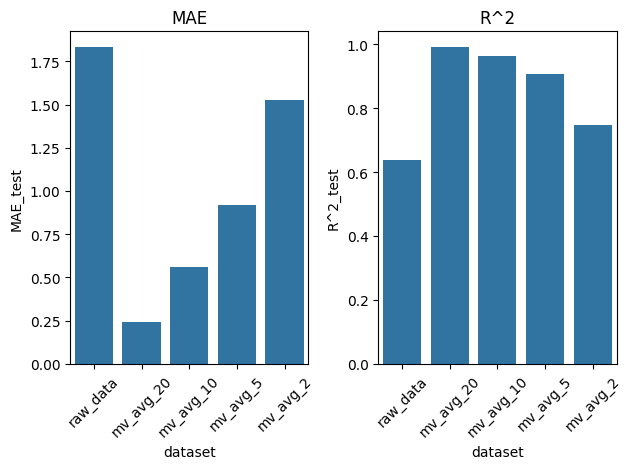

In [119]:
#MAEとR^2の推移を表示
result_df = pd.DataFrame(result_list)
lgb_results=result_df[result_df["model"]=="LightGBM"]

plt.subplot(1,2,1)
sns.barplot(lgb_results, x='dataset', y='MAE_test', errorbar=None)
plt.title('MAE')
plt.xticks(rotation=45)
plt.tight_layout()

plt.subplot(1,2,2)
sns.barplot(lgb_results, x='dataset', y='R^2_test', errorbar=None)
plt.xticks(rotation=45)
plt.title('R^2')
plt.tight_layout()

過去のデータ数を多く使用したデータほど予測精度が良い(MAEが小さくR^2が大きい)モデルが作成できた。

次に各センサのデータに"pl_vib_vec"を追加したデータセットでトライする。

In [120]:
path_pvec = '../data/processed/add_plane_vec.csv'
df = pd.read_csv(path_pvec)

X = df.drop(["tool_wear"], axis=1)
y = df["tool_wear"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

add_pvec_model = model.get_best_booster()

[I 2025-11-03 15:29:28,745] A new study created in memory with name: no-name-1cf03834-2f0a-469a-95c7-88269e3675f5
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.966486:  14%|8     | 1/7 [00:00<00:01,  3.23it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.950997:  29%|#7    | 2/7 [00:00<00:01,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.950997:  43%|##5   | 3/7 [00:00<00:01,  3.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.950997:  57%|###4  | 4/7 [00:01<00:00,  3.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.950997:  71%|####2 | 5/7 [00:01<00:00,  3.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.950722:  86%|#####1| 6/7 [00:01<00:00,  3.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.950722:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.950722:   5%|5          | 1/20 [00:00<00:06,  2.76it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.848971:  15%|#6         | 3/20 [00:00<00:06,  2.79it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.848971:  30%|###3       | 6/20 [00:01<00:02,  6.09it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training fro

num_leaves, val_score: 1.848971:  35%|###8       | 7/20 [00:01<00:02,  5.40it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.848971:  40%|####4      | 8/20 [00:01<00:02,  5.40it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.848971:  45%|####9      | 9/20 [00:01<00:02,  4.94it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.848971:  50%|#####     | 10/20 [00:02<00:02,  4.20it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.848971:  55%|#####5    | 11/20 [00:02<00:02,  3.74it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.848971:  60%|######    | 12/20 [00:02<00:02,  3.44it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.848971:  65%|######5   | 13/20 [00:03<00:02,  3.23it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.848971:  70%|#######   | 14/20 [00:03<00:01,  3.09it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.848971:  75%|#######5  | 15/20 [00:03<00:01,  3.09it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


num_leaves, val_score: 1.848971:  80%|########  | 16/20 [00:04<00:01,  3.67it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.848971:  85%|########5 | 17/20 [00:04<00:00,  3.59it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.848971:  95%|#########5| 19/20 [00:04<00:00,  3.33it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 1.848971:  40%|#####6        | 4/10 [00:00<00:00, 20.55it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training fro

bagging, val_score: 1.845684:  90%|############6 | 9/10 [00:00<00:00, 20.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training fro

bagging, val_score: 1.845684: 100%|#############| 10/10 [00:00<00:00, 20.09it/s]


[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 1.845684:  17%|1| 1/6 [00:00<00:00, 10.14it/[I 2025-11-03 15:29:36,543] Trial 38 finished with value: 1.8456838149146393 and parameters: {'feature_fraction': 0.852}. Best is trial 31 with value: 1.8456838149146393.
feature_fraction_stage2, val_score: 1.845684:  33%|3| 2/6 [00:00<00:00, 20.17it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training fro

feature_fraction_stage2, val_score: 1.845684:  50%|5| 3/6 [00:00<00:00, 20.14it/[I 2025-11-03 15:29:36,644] Trial 40 finished with value: 1.8456838149146393 and parameters: {'feature_fraction': 0.82}. Best is trial 31 with value: 1.8456838149146393.
feature_fraction_stage2, val_score: 1.845684:  67%|6| 4/6 [00:00<00:00, 20.14it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6


feature_fraction_stage2, val_score: 1.845684: 100%|#| 6/6 [00:00<00:00, 19.88it/[I 2025-11-03 15:29:36,746] Trial 42 finished with value: 1.8456838149146393 and parameters: {'feature_fraction': 0.9159999999999999}. Best is trial 31 with value: 1.8456838149146393.
feature_fraction_stage2, val_score: 1.845684: 100%|#| 6/6 [00:00<00:00, 19.88it/


[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.845684:   0%|       | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.845664:   0%|       | 0/20 [00:00<?, ?it/s][I 2025-11-03 15:29:36,798] Trial 43 finished with value: 1.8456641403099903 and parameters: {'lambda_l1': 0.01872596834565721, 'lambda_l2': 1.450622592996052e-05}. Best is trial 43 with value: 1.8456641403099903.
regularization_factors, val_score: 1.845664:   5%| | 1/20 [00:00<00:00, 19.28it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.845651:  10%|1| 2/20 [00:00<00:00, 19.54it/[I 2025-11-03 15:29:36,900] Trial 45 finished with value: 1.8456505980234912 and parameters: {'lambda_l1': 0.031623620192246474, 'lambda_l2': 1.5263362589055744e-05}. Best is trial 45 with value: 1.8456505980234912.
regularization_factors, val_score: 1.845651:  15%|1| 3/20 [00:00<00:00, 19.54it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.845651:  20%|2| 4/20 [00:00<00:00, 19.41it/[I 2025-11-03 15:29:36,953] Trial 46 finished with value: 1.8456725380540238 and parameters: {'lambda_l1': 0.010724519993340509, 'lambda_l2': 1.83919424180845e-05}. Best is trial 45 with value: 1.8456505980234912.
regularization_factors, val_score: 1.845651:  20%|2| 4/20 [00:00<00:00, 19.41it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.845651:  20%|2| 4/20 [00:00<00:00, 19.41it/[I 2025-11-03 15:29:37,004] Trial 47 finished with value: 1.8495605508913335 and parameters: {'lambda_l1': 0.04440020514602624, 'lambda_l2': 1.4911618303799941e-05}. Best is trial 45 with value: 1.8456505980234912.
regularization_factors, val_score: 1.845651:  25%|2| 5/20 [00:00<00:00, 19.41it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.845651:  30%|3| 6/20 [00:00<00:00, 19.43it/[I 2025-11-03 15:29:37,107] Trial 49 finished with value: 1.8495616496655827 and parameters: {'lambda_l1': 0.04325504034666258, 'lambda_l2': 2.1071446634642362e-05}. Best is trial 45 with value: 1.8456505980234912.
regularization_factors, val_score: 1.845651:  35%|3| 7/20 [00:00<00:00, 19.43it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.845651:  40%|4| 8/20 [00:00<00:00, 19.40it/[I 2025-11-03 15:29:37,159] Trial 50 finished with value: 1.845664854585909 and parameters: {'lambda_l1': 0.018042799850299312, 'lambda_l2': 1.815010119045499e-05}. Best is trial 45 with value: 1.8456505980234912.
regularization_factors, val_score: 1.845651:  40%|4| 8/20 [00:00<00:00, 19.40it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.845651:  45%|4| 9/20 [00:00<00:00, 19.40it/[I 2025-11-03 15:29:37,257] Trial 52 finished with value: 1.845662146364406 and parameters: {'lambda_l1': 0.020622407822939403, 'lambda_l2': 1.7547700046155623e-05}. Best is trial 45 with value: 1.8456505980234912.
regularization_factors, val_score: 1.845651:  50%|5| 10/20 [00:00<00:00, 19.40it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.845651:  55%|5| 11/20 [00:00<00:00, 19.69it[I 2025-11-03 15:29:37,360] Trial 54 finished with value: 1.8495639782160278 and parameters: {'lambda_l1': 0.04083951185055338, 'lambda_l2': 1.7016516536870637e-05}. Best is trial 45 with value: 1.8456505980234912.
regularization_factors, val_score: 1.845651:  60%|6| 12/20 [00:00<00:00, 19.69it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.845651:  65%|6| 13/20 [00:00<00:00, 19.57it[I 2025-11-03 15:29:37,412] Trial 55 finished with value: 1.84568355871942 and parameters: {'lambda_l1': 1.8188230106672086e-07, 'lambda_l2': 0.0002771700586658606}. Best is trial 45 with value: 1.8456505980234912.
regularization_factors, val_score: 1.845651:  65%|6| 13/20 [00:00<00:00, 19.57it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.845651:  75%|7| 15/20 [00:00<00:00, 19.55it[I 2025-11-03 15:29:37,515] Trial 57 finished with value: 1.8456834744227297 and parameters: {'lambda_l1': 0.0003235028291785057, 'lambda_l2': 7.399734978243723e-07}. Best is trial 45 with value: 1.8456505980234912.
regularization_factors, val_score: 1.845651:  75%|7| 15/20 [00:00<00:00, 19.55it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.845651:  75%|7| 15/20 [00:00<00:00, 19.55it[I 2025-11-03 15:29:37,566] Trial 58 finished with value: 1.8461818019068748 and parameters: {'lambda_l1': 0.712700037697039, 'lambda_l2': 0.0007927630663026096}. Best is trial 45 with value: 1.8456505980234912.
regularization_factors, val_score: 1.845651:  80%|8| 16/20 [00:00<00:00, 19.55it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.845651:  85%|8| 17/20 [00:00<00:00, 19.50it[I 2025-11-03 15:29:37,618] Trial 59 finished with value: 1.845682899146576 and parameters: {'lambda_l1': 0.0008710332951195199, 'lambda_l2': 1.3384531576916932e-06}. Best is trial 45 with value: 1.8456505980234912.
regularization_factors, val_score: 1.845651:  85%|8| 17/20 [00:00<00:00, 19.50it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.845651:  95%|9| 19/20 [00:00<00:00, 19.53it[I 2025-11-03 15:29:37,720] Trial 61 finished with value: 1.845679062836434 and parameters: {'lambda_l1': 0.004340720587640248, 'lambda_l2': 0.00021103539188109928}. Best is trial 45 with value: 1.8456505980234912.
regularization_factors, val_score: 1.845651:  95%|9| 19/20 [00:00<00:00, 19.53it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.845651:  95%|9| 19/20 [00:01<00:00, 19.53it[I 2025-11-03 15:29:37,771] Trial 62 finished with value: 1.8495498096173673 and parameters: {'lambda_l1': 0.05556366018074556, 'lambda_l2': 3.691869162736312e-06}. Best is trial 45 with value: 1.8456505980234912.
regularization_factors, val_score: 1.845651: 100%|#| 20/20 [00:01<00:00, 19.52it
min_child_samples, val_score: 1.845651:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.845651:  20%|#    | 1/5 [00:00<00:00, 19.45it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.845651:  60%|###  | 3/5 [00:00<00:00, 19.70it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000201 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.845651:  80%|#### | 4/5 [00:00<00:00, 19.73it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.845651: 100%|#####| 5/5 [00:00<00:00, 19.64it/s]

Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 4, 'learning_rate': 0.1, 'feature_fraction': 0.8999999999999999, 'bagging_freq': 6, 'bagging_fraction': 0.8298264263375995, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 0.031623620192246474, 'lambda_l2': 1.5263362589055744e-05, 'min_child_samples': 20}


In [121]:
train_predict = add_pvec_model.predict(X_train)
test_predict = add_pvec_model.predict(X_test)
MAE_train  =mean_absolute_error(y_train, train_predict)
MAE_test  =mean_absolute_error(y_test, test_predict)
R2_train = r2_score(y_train, train_predict)
R2_test = r2_score(y_test, test_predict)
result = {
    "model":"LightGBM",
    "dataset":"add_plane_vec",
    "MAE_train":mean_absolute_error(y_train, train_predict),
    "MAE_test":mean_absolute_error(y_test, test_predict),
    "R^2_train":r2_score(y_train, train_predict),
    "R^2_test":r2_score(y_test, test_predict)
}

pprint(result)
result_list.append(result)

{'MAE_test': 1.8456506047601926,
 'MAE_train': 1.6727080132663434,
 'R^2_test': 0.6353893129983155,
 'R^2_train': 0.7320186827063467,
 'dataset': 'add_plane_vec',
 'model': 'LightGBM'}


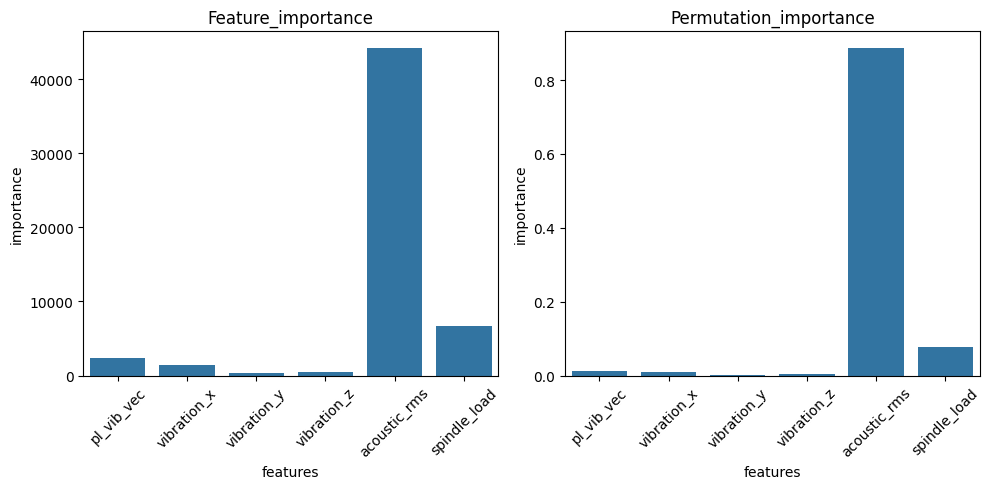

In [124]:
feature_importance_2 = pd.DataFrame(zip(X.columns, add_pvec_model.feature_importance(importance_type='gain')), columns=['features', 'importance'])

regressor_model = lgb.LGBMRegressor()
regressor_model._Booster = add_pvec_model
regressor_model._n_features = X_test.shape[1]
regressor_model.fitted_ = True
results_2 = permutation_importance(regressor_model, X_test, y_test, n_repeats=10, random_state=42)
purmutation_importance_2 = pd.DataFrame(zip(X.columns, results_2['importances'].mean(axis=1)), columns=['features', 'importance'])

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.barplot(feature_importance_2, x='features', y='importance', errorbar=None)
plt.xticks(rotation=45)
plt.title('Feature_importance')
plt.tight_layout()

plt.subplot(1,2,2)
sns.barplot(purmutation_importance_2, x='features', y='importance', errorbar=None)
plt.xticks(rotation=45)
plt.title('Permutation_importance')
plt.tight_layout()

In [147]:
result_df = pd.DataFrame(result_list)
con_df = pd.concat([result_df[(result_df["model"]=="LightGBM")&(result_df["dataset"]=="raw_data")],
           result_df[result_df["dataset"]=="add_plane_vec"]])

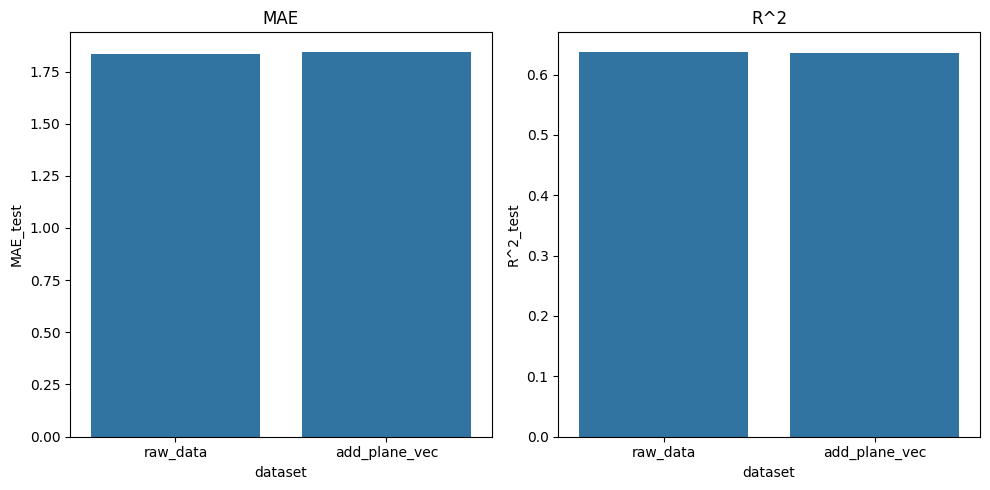

In [149]:
#MAEとR^2の推移を表示
result_df = pd.DataFrame(result_list)
con_df = pd.concat([result_df[(result_df["model"]=="LightGBM")&(result_df["dataset"]=="raw_data")],
           result_df[result_df["dataset"]=="add_plane_vec"]])

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.barplot(con_df, x='dataset', y='MAE_test', errorbar=None)
plt.title('MAE')
plt.tight_layout()

plt.subplot(1,2,2)
sns.barplot(con_df, x='dataset', y='R^2_test', errorbar=None)
plt.title('R^2')
plt.tight_layout()

生データと"pl_vib_vec"を追加したデータセットでMAEもR^2もほぼ変わらなかった(MAE変化率 -0.5%)。特徴量の重要度評価からも、追加した特徴量はあまりモデルの予測精度には寄与しなかったことが分かる。

複数回の加工のデータの移動平均を使用することでモデルの予測精度を高めることができたが、１回の加工単位ではセンサー値のブレが大きく、特徴量化が難しいと考える。

続いて、必要なセンサを確認するため、重要度評価が低いセンサのデータを削減してモデルを再度作成する。使用するデータセットは、生データと作成した中で最も予測精度の良いモデルを作成できた、20回の加工データの移動平均をとったデータセット。

In [151]:
#生データから重要度評価が最も低い特徴量を削除して再評価
path = '../data/raw/Milling_Tool_Dataset.csv'
df = pd.read_csv(path)

X = df[["vibration_x", "vibration_y", "acoustic_rms", "spindle_load"]]
y = df["tool_wear"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

z_del_model = model.get_best_booster()

[I 2025-11-03 15:45:06,365] A new study created in memory with name: no-name-e9873e1e-b124-4243-b35c-ccf17de8d40a
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.990633:  14%|8     | 1/7 [00:00<00:01,  3.18it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.990633:  29%|#7    | 2/7 [00:00<00:01,  3.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000140 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.990633:  43%|##5   | 3/7 [00:00<00:01,  3.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.990633:  57%|###4  | 4/7 [00:01<00:00,  3.34it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.990633:  71%|####2 | 5/7 [00:01<00:00,  3.35it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.990633:  86%|#####1| 6/7 [00:01<00:00,  3.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.990633:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.990633:   5%|5          | 1/20 [00:00<00:06,  3.10it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.981877:  10%|#1         | 2/20 [00:00<00:06,  2.86it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.981877:  15%|#6         | 3/20 [00:01<00:05,  2.84it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.981877:  20%|##2        | 4/20 [00:01<00:05,  2.80it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.981877:  25%|##7        | 5/20 [00:01<00:05,  2.77it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

num_leaves, val_score: 1.981877:  25%|##7        | 5/20 [00:02<00:05,  2.77it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.981877:  30%|###3       | 6/20 [00:02<00:05,  2.76it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.981877:  35%|###8       | 7/20 [00:02<00:04,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.981877:  40%|####4      | 8/20 [00:02<00:04,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.981877:  45%|####9      | 9/20 [00:03<00:03,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.981877:  50%|#####     | 10/20 [00:03<00:03,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 secon

num_leaves, val_score: 1.981877:  50%|#####     | 10/20 [00:03<00:03,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.867645:  70%|#######   | 14/20 [00:04<00:01,  4.44it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000085 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training fro

num_leaves, val_score: 1.867645:  80%|########  | 16/20 [00:04<00:00,  7.27it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

num_leaves, val_score: 1.855864:  90%|######### | 18/20 [00:04<00:00,  6.43it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

num_leaves, val_score: 1.855864:  95%|#########5| 19/20 [00:05<00:00,  5.13it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 1.826190:  60%|########4     | 6/10 [00:00<00:00, 33.41it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training fro

bagging, val_score: 1.826190: 100%|#############| 10/10 [00:00<00:00, 32.55it/s]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training fro

feature_fraction_stage2, val_score: 1.826190:  67%|6| 2/3 [00:00<00:00, 21.40it/[I 2025-11-03 15:45:14,151] Trial 39 finished with value: 1.826190039000017 and parameters: {'feature_fraction': 0.92}. Best is trial 31 with value: 1.826190039000017.
feature_fraction_stage2, val_score: 1.826190: 100%|#| 3/3 [00:00<00:00, 31.94it/


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.826190:   0%|       | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.826190:  10%|1| 2/20 [00:00<00:00, 20.91it/[I 2025-11-03 15:45:14,248] Trial 42 finished with value: 1.8261900389725958 and parameters: {'lambda_l1': 1.105111320186287e-08, 'lambda_l2': 1.6596866467653675e-07}. Best is trial 42 with value: 1.8261900389725958.
regularization_factors, val_score: 1.826190:  15%|1| 3/20 [00:00<00:00, 31.24it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.826190:  25%|2| 5/20 [00:00<00:00, 31.61it/[I 2025-11-03 15:45:14,342] Trial 45 finished with value: 1.8261900390083812 and parameters: {'lambda_l1': 1.0976400186484311e-08, 'lambda_l2': 1.873705974469401e-08}. Best is trial 42 with value: 1.8261900389725958.
regularization_factors, val_score: 1.826190:  30%|3| 6/20 [00:00<00:00, 31.61it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000064 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.826190:  30%|3| 6/20 [00:00<00:00, 31.61it/[I 2025-11-03 15:45:14,369] Trial 46 finished with value: 1.8261900393144783 and parameters: {'lambda_l1': 1.200836243397643e-08, 'lambda_l2': 1.8649883897104225e-06}. Best is trial 42 with value: 1.8261900389725958.
regularization_factors, val_score: 1.826190:  35%|3| 7/20 [00:00<00:00, 31.61it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.825939:  45%|4| 9/20 [00:00<00:00, 32.83it/[I 2025-11-03 15:45:14,459] Trial 49 finished with value: 1.8259391045693307 and parameters: {'lambda_l1': 0.0037623971931215914, 'lambda_l2': 0.7713300825593302}. Best is trial 49 with value: 1.8259391045693307.
regularization_factors, val_score: 1.825939:  50%|5| 10/20 [00:00<00:00, 32.83it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.825939:  60%|6| 12/20 [00:00<00:00, 32.68it[I 2025-11-03 15:45:14,555] Trial 52 finished with value: 1.8262134101041196 and parameters: {'lambda_l1': 0.003917540647267413, 'lambda_l2': 0.12883378166428555}. Best is trial 49 with value: 1.8259391045693307.
regularization_factors, val_score: 1.825939:  65%|6| 13/20 [00:00<00:00, 32.68it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000157 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.825939:  65%|6| 13/20 [00:00<00:00, 32.68it[I 2025-11-03 15:45:14,588] Trial 53 finished with value: 1.826189970947484 and parameters: {'lambda_l1': 0.11199353470018555, 'lambda_l2': 8.856711269268479e-07}. Best is trial 49 with value: 1.8259391045693307.
regularization_factors, val_score: 1.825939:  70%|7| 14/20 [00:00<00:00, 32.68it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.825939:  80%|8| 16/20 [00:00<00:00, 31.42it[I 2025-11-03 15:45:14,689] Trial 56 finished with value: 1.8261882752782903 and parameters: {'lambda_l1': 0.16066393671286922, 'lambda_l2': 2.2594103198290956e-07}. Best is trial 49 with value: 1.8259391045693307.
regularization_factors, val_score: 1.825939:  85%|8| 17/20 [00:00<00:00, 31.42it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000171 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.


regularization_factors, val_score: 1.825939: 100%|#| 20/20 [00:00<00:00, 31.17it[I 2025-11-03 15:45:14,786] Trial 59 finished with value: 1.8261873710906027 and parameters: {'lambda_l1': 0.0768352336956397, 'lambda_l2': 2.634851264053037e-05}. Best is trial 49 with value: 1.8259391045693307.
regularization_factors, val_score: 1.825939: 100%|#| 20/20 [00:00<00:00, 31.56it


[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.825939:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.825939:  20%|#    | 1/5 [00:00<00:00, 29.72it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.825130:  60%|###  | 3/5 [00:00<00:00, 31.70it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.825130: 100%|#####| 5/5 [00:00<00:00, 32.21it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 2, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_freq': 3, 'bagging_fraction': 0.5370773874541831, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 0.0037623971931215914, 'lambda_l2': 0.7713300825593302, 'min_child_samples': 5}


In [152]:
train_predict = z_del_model.predict(X_train)
test_predict = z_del_model.predict(X_test)
MAE_train  =mean_absolute_error(y_train, train_predict)
MAE_test  =mean_absolute_error(y_test, test_predict)
R2_train = r2_score(y_train, train_predict)
R2_test = r2_score(y_test, test_predict)
result = {
    "model":"LightGBM",
    "dataset":"raw_data_del_z",
    "MAE_train":mean_absolute_error(y_train, train_predict),
    "MAE_test":mean_absolute_error(y_test, test_predict),
    "R^2_train":r2_score(y_train, train_predict),
    "R^2_test":r2_score(y_test, test_predict)
}

pprint(result)
result_list.append(result)

{'MAE_test': 1.8251297170295402,
 'MAE_train': 1.8053663404857807,
 'R^2_test': 0.6380278525271464,
 'R^2_train': 0.6898571959525572,
 'dataset': 'raw_data_del_z',
 'model': 'LightGBM'}


In [153]:
#MAEが元データの5%下がるまで特徴量の削除を続行
X = df[["vibration_x", "acoustic_rms", "spindle_load"]]
y = df["tool_wear"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

yz_del_model = model.get_best_booster()

[I 2025-11-03 15:46:51,619] A new study created in memory with name: no-name-ab4ac412-c805-4757-b879-fabeea876ee7
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.963070:  14%|8     | 1/7 [00:00<00:01,  3.13it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.963070:  29%|#7    | 2/7 [00:00<00:01,  3.23it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.963070:  43%|##5   | 3/7 [00:00<00:01,  3.25it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.963070:  57%|###4  | 4/7 [00:01<00:00,  3.34it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.963070:  71%|####2 | 5/7 [00:01<00:00,  3.36it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000183 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.963070:  86%|#####1| 6/7 [00:01<00:00,  3.38it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.963070:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 1.963070:   5%|5          | 1/20 [00:00<00:06,  2.81it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.963070:  10%|#1         | 2/20 [00:00<00:06,  2.82it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.878150:  25%|##7        | 5/20 [00:01<00:02,  5.17it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-ch

num_leaves, val_score: 1.857676:  35%|###8       | 7/20 [00:01<00:02,  5.17it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

num_leaves, val_score: 1.857676:  40%|####4      | 8/20 [00:01<00:02,  5.60it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.857676:  45%|####9      | 9/20 [00:02<00:02,  4.70it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 1.857676:  50%|#####     | 10/20 [00:02<00:02,  4.04it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.857676:  55%|#####5    | 11/20 [00:02<00:02,  3.68it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.857676:  60%|######    | 12/20 [00:03<00:02,  3.40it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.857676:  65%|######5   | 13/20 [00:03<00:02,  3.21it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


num_leaves, val_score: 1.857676:  70%|#######   | 14/20 [00:03<00:01,  3.14it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.857676:  80%|########  | 16/20 [00:03<00:00,  4.67it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

num_leaves, val_score: 1.857676:  90%|######### | 18/20 [00:04<00:00,  4.01it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train se

num_leaves, val_score: 1.857676:  95%|#########5| 19/20 [00:04<00:00,  4.43it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 1.857676: 100%|##########| 20/20 [00:05<00:00,  3.93it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 1.842775:  10%|#4            | 1/10 [00:00<00:00, 27.82it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 1.842775:  60%|########4     | 6/10 [00:00<00:00, 30.37it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from s

bagging, val_score: 1.842775:  80%|###########2  | 8/10 [00:00<00:00, 30.92it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000134 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 1.842775: 100%|#############| 10/10 [00:00<00:00, 30.51it/s]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 1.842775:  33%|3| 1/3 [00:00<00:00, 13.06it/[I 2025-11-03 15:46:59,207] Trial 38 finished with value: 1.8427745307136534 and parameters: {'feature_fraction': 0.9840000000000001}. Best is trial 27 with value: 1.8427745307136534.
feature_fraction_stage2, val_score: 1.842775:  67%|6| 2/3 [00:00<00:00, 25.96it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from s

feature_fraction_stage2, val_score: 1.842775: 100%|#| 3/3 [00:00<00:00, 26.21it/[I 2025-11-03 15:46:59,245] Trial 39 finished with value: 1.8427745307136534 and parameters: {'feature_fraction': 0.92}. Best is trial 27 with value: 1.8427745307136534.
feature_fraction_stage2, val_score: 1.842775: 100%|#| 3/3 [00:00<00:00, 26.09it/
regularization_factors, val_score: 1.842765:   0%|       | 0/20 [00:00<?, ?it/s][I 2025-11-03 15:46:59,286] Trial 40 finished with value: 1.8427647961811346 and parameters: {'lambda_l1': 0.020206263851919527, 'lambda_l2': 2.3794466140151993e-05}. Best is trial 40 with value: 1.8427647961811346.
regularization_factors, val_score: 1.842765:   5%| | 1/20 [00:00<00:00, 25.22it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.842760:   5%| | 1/20 [00:00<00:01, 12.84it/[I 2025-11-03 15:46:59,324] Trial 41 finished with value: 1.8427600027552151 and parameters: {'lambda_l1': 0.030172667305101927, 'lambda_l2': 1.5138860150547252e-05}. Best is trial 41 with value: 1.8427600027552151.
regularization_factors, val_score: 1.842760:  10%|1| 2/20 [00:00<00:00, 25.53it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.842759:  20%|2| 4/20 [00:00<00:00, 25.71it/[I 2025-11-03 15:46:59,441] Trial 44 finished with value: 1.842761226816556 and parameters: {'lambda_l1': 0.02763319341063698, 'lambda_l2': 1.0576256579370135e-05}. Best is trial 42 with value: 1.8427590640751375.
regularization_factors, val_score: 1.842759:  25%|2| 5/20 [00:00<00:00, 25.71it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from s

regularization_factors, val_score: 1.842759:  30%|3| 6/20 [00:00<00:00, 25.73it/[I 2025-11-03 15:46:59,518] Trial 46 finished with value: 1.8427597193164533 and parameters: {'lambda_l1': 0.03076739518483063, 'lambda_l2': 8.37009525557874e-06}. Best is trial 42 with value: 1.8427590640751375.
regularization_factors, val_score: 1.842759:  35%|3| 7/20 [00:00<00:00, 25.73it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.842759:  35%|3| 7/20 [00:00<00:00, 25.73it/[I 2025-11-03 15:46:59,556] Trial 47 finished with value: 1.8427613205176838 and parameters: {'lambda_l1': 0.027439573888713747, 'lambda_l2': 9.20191291094731e-06}. Best is trial 42 with value: 1.8427590640751375.
regularization_factors, val_score: 1.842759:  40%|4| 8/20 [00:00<00:00, 25.73it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.842754:  50%|5| 10/20 [00:00<00:00, 25.82it[I 2025-11-03 15:46:59,664] Trial 50 finished with value: 1.8492050068386585 and parameters: {'lambda_l1': 5.408390053098901, 'lambda_l2': 2.8698716041074097e-07}. Best is trial 48 with value: 1.8427535469688787.
regularization_factors, val_score: 1.842754:  55%|5| 11/20 [00:00<00:00, 25.82it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from s

regularization_factors, val_score: 1.842751:  60%|6| 12/20 [00:00<00:00, 26.94it[I 2025-11-03 15:46:59,739] Trial 52 finished with value: 1.8427505151744912 and parameters: {'lambda_l1': 0.049892890508333655, 'lambda_l2': 5.672489117474061e-06}. Best is trial 52 with value: 1.8427505151744912.
regularization_factors, val_score: 1.842751:  65%|6| 13/20 [00:00<00:00, 26.94it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000156 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000188 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.842751:  65%|6| 13/20 [00:00<00:00, 26.94it[I 2025-11-03 15:46:59,778] Trial 53 finished with value: 1.8445901359545156 and parameters: {'lambda_l1': 0.31308270493193807, 'lambda_l2': 0.019661350455963116}. Best is trial 52 with value: 1.8427505151744912.
regularization_factors, val_score: 1.842751:  70%|7| 14/20 [00:00<00:00, 26.94it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.842751:  80%|8| 16/20 [00:00<00:00, 26.34it[I 2025-11-03 15:46:59,897] Trial 56 finished with value: 1.842774530575268 and parameters: {'lambda_l1': 1.5617086296916568e-07, 'lambda_l2': 8.348074269469967e-07}. Best is trial 52 with value: 1.8427505151744912.
regularization_factors, val_score: 1.842751:  85%|8| 17/20 [00:00<00:00, 26.34it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from s

regularization_factors, val_score: 1.842751:  90%|9| 18/20 [00:00<00:00, 25.90it[I 2025-11-03 15:46:59,977] Trial 58 finished with value: 1.8427738826219149 and parameters: {'lambda_l1': 0.0013467891512716212, 'lambda_l2': 1.0077113991045717e-08}. Best is trial 52 with value: 1.8427505151744912.
regularization_factors, val_score: 1.842751:  95%|9| 19/20 [00:00<00:00, 25.90it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.842751:  95%|9| 19/20 [00:00<00:00, 25.90it[I 2025-11-03 15:47:00,015] Trial 59 finished with value: 1.8445576508672579 and parameters: {'lambda_l1': 0.41061042799013303, 'lambda_l2': 8.836204864028392e-07}. Best is trial 52 with value: 1.8427505151744912.
regularization_factors, val_score: 1.842751: 100%|#| 20/20 [00:00<00:00, 26.03it
min_child_samples, val_score: 1.842751:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.841548:  60%|###  | 3/5 [00:00<00:00, 27.15it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from s

min_child_samples, val_score: 1.838899: 100%|#####| 5/5 [00:00<00:00, 27.06it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 2, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_freq': 1, 'bagging_fraction': 0.47018048453237876, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 0.049892890508333655, 'lambda_l2': 5.672489117474061e-06, 'min_child_samples': 10}


In [155]:
train_predict = yz_del_model.predict(X_train)
test_predict = yz_del_model.predict(X_test)
MAE_train  =mean_absolute_error(y_train, train_predict)
MAE_test  =mean_absolute_error(y_test, test_predict)
R2_train = r2_score(y_train, train_predict)
R2_test = r2_score(y_test, test_predict)
result = {
    "model":"LightGBM",
    "dataset":"raw_data_del_yz",
    "MAE_train":mean_absolute_error(y_train, train_predict),
    "MAE_test":mean_absolute_error(y_test, test_predict),
    "R^2_train":r2_score(y_train, train_predict),
    "R^2_test":r2_score(y_test, test_predict)
}

pprint(result)
result_list.append(result)

{'MAE_test': 1.8388994542441308,
 'MAE_train': 1.8276475588906922,
 'R^2_test': 0.6387425823839239,
 'R^2_train': 0.685370357986291,
 'dataset': 'raw_data_del_yz',
 'model': 'LightGBM'}


In [24]:
X = df[["acoustic_rms", "spindle_load"]]
y = df["tool_wear"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

vib_del_model = model.get_best_booster()

[I 2025-11-03 09:25:20,588] A new study created in memory with name: no-name-ca571599-8d28-497b-8fc3-0ced07d706ee
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.959869:  14%|8     | 1/7 [00:00<00:01,  3.17it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.959869:  29%|#7    | 2/7 [00:00<00:01,  3.23it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.959869:  43%|##5   | 3/7 [00:00<00:01,  3.24it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.959869:  57%|###4  | 4/7 [00:01<00:00,  3.26it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.959869:  71%|####2 | 5/7 [00:01<00:00,  3.25it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.959869:  86%|#####1| 6/7 [00:01<00:00,  3.26it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.959869:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 1.959869:   5%|5          | 1/20 [00:00<00:06,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.959869:  10%|#1         | 2/20 [00:00<00:06,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.959869:  15%|#6         | 3/20 [00:01<00:06,  2.76it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.888318:  30%|###3       | 6/20 [00:01<00:02,  5.03it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train se

num_leaves, val_score: 1.888318:  40%|####4      | 8/20 [00:01<00:01,  6.75it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

num_leaves, val_score: 1.888318:  45%|####9      | 9/20 [00:02<00:02,  5.06it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 1.888318:  50%|#####     | 10/20 [00:02<00:02,  4.19it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.888318:  60%|######    | 12/20 [00:02<00:02,  3.68it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.888318:  65%|######5   | 13/20 [00:03<00:01,  4.15it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.888318:  75%|#######5  | 15/20 [00:03<00:01,  3.71it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.888318:  80%|########  | 16/20 [00:03<00:00,  4.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000064 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.888318:  90%|######### | 18/20 [00:04<00:00,  3.95it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

num_leaves, val_score: 1.888318:  95%|#########5| 19/20 [00:04<00:00,  4.16it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

bagging, val_score: 1.874558:  70%|#########7    | 7/10 [00:00<00:00, 35.52it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000063 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from s

bagging, val_score: 1.874558: 100%|#############| 10/10 [00:00<00:00, 34.30it/s]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000081 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 1.874558:  67%|6| 2/3 [00:00<00:00, 24.20it/[I 2025-11-03 09:25:28,145] Trial 39 finished with value: 1.874558133590551 and parameters: {'feature_fraction': 0.92}. Best is trial 30 with value: 1.874558133590551.
feature_fraction_stage2, val_score: 1.874558: 100%|#| 3/3 [00:00<00:00, 36.06it/


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from s

regularization_factors, val_score: 1.874249:   0%|       | 0/20 [00:00<?, ?it/s][I 2025-11-03 09:25:28,174] Trial 40 finished with value: 1.8742488208776593 and parameters: {'lambda_l1': 1.1229660741781571e-06, 'lambda_l2': 0.0762025761571628}. Best is trial 40 with value: 1.8742488208776593.
regularization_factors, val_score: 1.874249:   5%| | 1/20 [00:00<00:00, 34.68it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.873690:  20%|2| 4/20 [00:00<00:00, 34.73it/[I 2025-11-03 09:25:28,261] Trial 43 finished with value: 1.873690273173298 and parameters: {'lambda_l1': 2.946835679268882e-07, 'lambda_l2': 0.26109435917708884}. Best is trial 43 with value: 1.873690273173298.
regularization_factors, val_score: 1.873690:  20%|2| 4/20 [00:00<00:00, 34.73it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from s

regularization_factors, val_score: 1.873688:  25%|2| 5/20 [00:00<00:00, 34.73it/[I 2025-11-03 09:25:28,321] Trial 45 finished with value: 1.8736879523450145 and parameters: {'lambda_l1': 2.30950719808002e-07, 'lambda_l2': 0.2049933569850269}. Best is trial 45 with value: 1.8736879523450145.
regularization_factors, val_score: 1.873688:  30%|3| 6/20 [00:00<00:00, 34.73it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.873688:  40%|4| 8/20 [00:00<00:00, 33.98it/[I 2025-11-03 09:25:28,381] Trial 47 finished with value: 1.873752404426984 and parameters: {'lambda_l1': 1.1031448090452164e-07, 'lambda_l2': 0.3676635755389015}. Best is trial 45 with value: 1.8736879523450145.
regularization_factors, val_score: 1.873688:  40%|4| 8/20 [00:00<00:00, 33.98it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.873688:  50%|5| 10/20 [00:00<00:00, 33.98it[I 2025-11-03 09:25:28,470] Trial 50 finished with value: 1.8781780426162755 and parameters: {'lambda_l1': 7.969138333147079, 'lambda_l2': 2.3797434377169674e-06}. Best is trial 45 with value: 1.8736879523450145.
regularization_factors, val_score: 1.873688:  55%|5| 11/20 [00:00<00:00, 33.98it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from s

regularization_factors, val_score: 1.873688:  60%|6| 12/20 [00:00<00:00, 33.72it[I 2025-11-03 09:25:28,534] Trial 52 finished with value: 1.8738550559545597 and parameters: {'lambda_l1': 9.157172606576182e-08, 'lambda_l2': 0.16016645517837916}. Best is trial 45 with value: 1.8736879523450145.
regularization_factors, val_score: 1.873688:  65%|6| 13/20 [00:00<00:00, 33.72it

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.873688:  70%|7| 14/20 [00:00<00:00, 33.72it[I 2025-11-03 09:25:28,593] Trial 54 finished with value: 1.8745589806517047 and parameters: {'lambda_l1': 1.8593797303153832e-08, 'lambda_l2': 0.005197485511815292}. Best is trial 45 with value: 1.8736879523450145.
regularization_factors, val_score: 1.873688:  75%|7| 15/20 [00:00<00:00, 33.72it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.873688:  85%|8| 17/20 [00:00<00:00, 33.28it[I 2025-11-03 09:25:28,683] Trial 57 finished with value: 1.8745620605754487 and parameters: {'lambda_l1': 3.307068764980898e-06, 'lambda_l2': 0.024069103853265612}. Best is trial 45 with value: 1.8736879523450145.
regularization_factors, val_score: 1.873688:  90%|9| 18/20 [00:00<00:00, 33.28it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from s

regularization_factors, val_score: 1.873688: 100%|#| 20/20 [00:00<00:00, 33.25it[I 2025-11-03 09:25:28,743] Trial 59 finished with value: 1.8745610700886506 and parameters: {'lambda_l1': 8.139256591547592e-07, 'lambda_l2': 0.018001409925475477}. Best is trial 45 with value: 1.8736879523450145.
regularization_factors, val_score: 1.873688: 100%|#| 20/20 [00:00<00:00, 33.45it


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.873688:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.871253:  40%|##   | 2/5 [00:00<00:00, 33.91it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.871253: 100%|#####| 5/5 [00:00<00:00, 34.02it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000062 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 2, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_freq': 5, 'bagging_fraction': 0.888267196787217, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 2.30950719808002e-07, 'lambda_l2': 0.2049933569850269, 'min_child_samples': 100}


In [25]:
train_predict = vib_del_model.predict(X_train)
test_predict = vib_del_model.predict(X_test)
MAE_train  =mean_absolute_error(y_train, train_predict)
MAE_test  =mean_absolute_error(y_test, test_predict)
R2_train = r2_score(y_train, train_predict)
R2_test = r2_score(y_test, test_predict)
result = {
    "model":"LightGBM",
    "dataset":"raw_data_del_vib",
    "MAE_train":mean_absolute_error(y_train, train_predict),
    "MAE_test":mean_absolute_error(y_test, test_predict),
    "R^2_train":r2_score(y_train, train_predict),
    "R^2_test":r2_score(y_test, test_predict)
}

pprint(result)
result_list.append(result)

MAE train:1.878, MAE test:1.871
R^2 train:0.670, R^2 test:0.630


MAE: 2.105
R²: 0.587
回帰式: tool_wear = 40.3962 * acoustic_rms + -17.1735


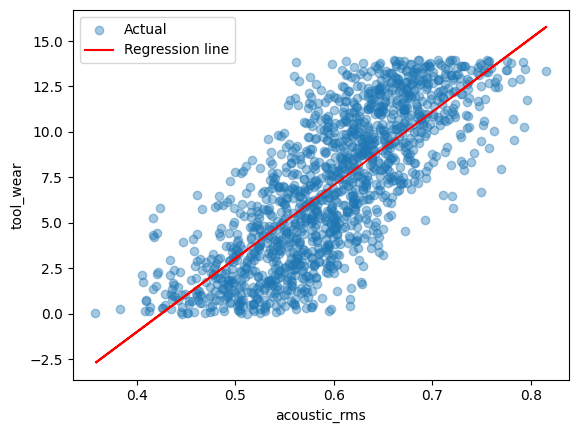

In [162]:
from sklearn.linear_model import LinearRegression
X = df[['acoustic_rms']]
y = df['tool_wear']

model = LinearRegression()
model.fit(X, y)
y_predict = model.predict(X)

print(f"MAE: {mean_absolute_error(y, y_predict):.3f}")
print(f"R²: {r2_score(y, y_predict):.3f}")
print(f"回帰式: tool_wear = {model.coef_[0]:.4f} * acoustic_rms + {model.intercept_:.4f}")

plt.scatter(X, y, alpha=0.4, label='Actual')
plt.plot(X, y_predict, color='red', label='Regression line')
plt.xlabel('acoustic_rms')
plt.ylabel('tool_wear')
plt.legend()
plt.show()

生データから振動データ(vibration_x, vibration_y, vibration_z)を削除しても、予測精度はほとんど変わらなかった(MSEの変化率 +1.5%)。

さらに"spindle_load"を削除し、"acoustic_rms"のみを使用して単回帰分析を行った。この分析の評価は R^2=0.587, MAE=2.105であり、"acoustic_rms"のみでもある程度"tool_wear"を説明できている。

以上から、音響データ(acoustic_rms)が振動データやスピンドル負荷(spindle_load)データを内包している可能性が考えられる。

続いて、20回分の加工データの移動平均を使用したデータセットでも、振動データと"spindle_load"を除去してモデルを作成し、MAEの変化を確認する。

In [164]:
path_avg20 = '../data/processed/mv_avg_20.csv'
df = pd.read_csv(path_avg20)

X = df[["mv_avg_ar", "mv_avg_sl"]]
y = df["tool_wear"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

avg20_vib_del_model = model.get_best_booster()

[I 2025-11-03 16:01:27,067] A new study created in memory with name: no-name-9c5c7f66-889d-4999-afbe-4722d724a4fe
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.403093:  14%|8     | 1/7 [00:00<00:01,  3.36it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.403093:  29%|#7    | 2/7 [00:00<00:01,  3.40it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.403093:  43%|##5   | 3/7 [00:00<00:01,  3.35it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.403093:  57%|###4  | 4/7 [00:01<00:00,  3.35it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.403093:  71%|####2 | 5/7 [00:01<00:00,  3.35it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.403093:  86%|#####1| 6/7 [00:01<00:00,  3.35it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 0.403093:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 0.402789:   5%|5          | 1/20 [00:00<00:06,  2.89it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  10%|#1         | 2/20 [00:00<00:06,  2.91it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  15%|#6         | 3/20 [00:01<00:05,  2.88it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 0.402789:  20%|##2        | 4/20 [00:01<00:05,  2.82it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  25%|##7        | 5/20 [00:01<00:05,  2.79it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  30%|###3       | 6/20 [00:02<00:05,  2.78it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  35%|###8       | 7/20 [00:02<00:04,  2.77it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  40%|####4      | 8/20 [00:02<00:04,  2.76it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 0.402789:  45%|####9      | 9/20 [00:03<00:03,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  50%|#####     | 10/20 [00:03<00:03,  2.75it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 0.402789:  55%|#####5    | 11/20 [00:03<00:02,  3.46it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  60%|######    | 12/20 [00:03<00:02,  3.27it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  65%|######5   | 13/20 [00:04<00:02,  3.13it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  70%|#######   | 14/20 [00:04<00:01,  3.02it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 0.402789:  75%|#######5  | 15/20 [00:05<00:01,  2.96it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  80%|########  | 16/20 [00:05<00:01,  2.93it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  85%|########5 | 17/20 [00:05<00:01,  2.90it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  90%|######### | 18/20 [00:06<00:00,  2.86it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 0.402789:  95%|#########5| 19/20 [00:06<00:00,  2.82it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789: 100%|##########| 20/20 [00:06<00:00,  2.91it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.402789:   0%|                      | 0/10 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

bagging, val_score: 0.402789:  10%|#4            | 1/10 [00:00<00:01,  5.19it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.402789:  20%|##8           | 2/10 [00:00<00:02,  3.40it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.402789:  30%|####2         | 3/10 [00:00<00:02,  3.31it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

bagging, val_score: 0.402789:  40%|#####6        | 4/10 [00:01<00:01,  4.05it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

bagging, val_score: 0.402789:  50%|#######       | 5/10 [00:01<00:01,  4.10it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

bagging, val_score: 0.402789:  60%|########4     | 6/10 [00:01<00:00,  4.01it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.402789:  70%|#########7    | 7/10 [00:01<00:00,  4.18it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.401992:  80%|###########2  | 8/10 [00:02<00:00,  3.85it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

bagging, val_score: 0.401992:  90%|############6 | 9/10 [00:02<00:00,  3.64it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.401992: 100%|#############| 10/10 [00:02<00:00,  3.69it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


feature_fraction_stage2, val_score: 0.401992:   0%|       | 0/3 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

feature_fraction_stage2, val_score: 0.401992:  33%|3| 1/3 [00:00<00:00,  3.27it/[I 2025-11-03 16:01:39,054] Trial 37 finished with value: 0.40199194843372943 and parameters: {'feature_fraction': 0.9520000000000001}. Best is trial 34 with value: 0.40199194843372943.
feature_fraction_stage2, val_score: 0.401992:  33%|3| 1/3 [00:00<00:00,  3.27it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

feature_fraction_stage2, val_score: 0.401992:  33%|3| 1/3 [00:00<00:00,  3.27it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


feature_fraction_stage2, val_score: 0.401992:  67%|6| 2/3 [00:00<00:00,  3.29it/[I 2025-11-03 16:01:39,356] Trial 38 finished with value: 0.40199194843372943 and parameters: {'feature_fraction': 0.9840000000000001}. Best is trial 34 with value: 0.40199194843372943.
feature_fraction_stage2, val_score: 0.401992:  67%|6| 2/3 [00:00<00:00,  3.29it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

feature_fraction_stage2, val_score: 0.401992: 100%|#| 3/3 [00:00<00:00,  3.33it/[I 2025-11-03 16:01:39,653] Trial 39 finished with value: 0.40199194843372943 and parameters: {'feature_fraction': 0.92}. Best is trial 34 with value: 0.40199194843372943.
feature_fraction_stage2, val_score: 0.401992: 100%|#| 3/3 [00:00<00:00,  3.32it/


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.401992:   0%|       | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.401992:   5%| | 1/20 [00:00<00:05,  3.27it/[I 2025-11-03 16:01:39,959] Trial 40 finished with value: 0.40199194837696756 and parameters: {'lambda_l1': 1.7166243951548794e-08, 'lambda_l2': 2.134498123208206e-07}. Best is trial 40 with value: 0.40199194837696756.
regularization_factors, val_score: 0.401992:   5%| | 1/20 [00:00<00:05,  3.27it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from sc

regularization_factors, val_score: 0.401992:  10%|1| 2/20 [00:00<00:05,  3.27it/[I 2025-11-03 16:01:40,265] Trial 41 finished with value: 0.401991948359845 and parameters: {'lambda_l1': 1.9644895475339492e-08, 'lambda_l2': 3.8604701501349743e-08}. Best is trial 41 with value: 0.401991948359845.
regularization_factors, val_score: 0.401992:  10%|1| 2/20 [00:00<00:05,  3.27it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.401992:  15%|1| 3/20 [00:00<00:05,  3.27it/[I 2025-11-03 16:01:40,572] Trial 42 finished with value: 0.4019919483449946 and parameters: {'lambda_l1': 1.9957790418445057e-08, 'lambda_l2': 2.9237124458562993e-08}. Best is trial 42 with value: 0.4019919483449946.
regularization_factors, val_score: 0.401992:  15%|1| 3/20 [00:00<00:05,  3.27it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.401992:  20%|2| 4/20 [00:01<00:04,  3.26it/[I 2025-11-03 16:01:40,880] Trial 43 finished with value: 0.4019919484008277 and parameters: {'lambda_l1': 1.152273864733885e-08, 'lambda_l2': 2.6917922326487647e-08}. Best is trial 42 with value: 0.4019919483449946.
regularization_factors, val_score: 0.401992:  20%|2| 4/20 [00:01<00:04,  3.26it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.401992:  25%|2| 5/20 [00:01<00:04,  3.31it/[I 2025-11-03 16:01:41,174] Trial 44 finished with value: 0.40199194845382963 and parameters: {'lambda_l1': 1.1417738108495627e-08, 'lambda_l2': 1.9114570292491956e-08}. Best is trial 42 with value: 0.4019919483449946.
regularization_factors, val_score: 0.401992:  25%|2| 5/20 [00:01<00:04,  3.31it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from sc

regularization_factors, val_score: 0.401992:  30%|3| 6/20 [00:01<00:04,  3.29it/[I 2025-11-03 16:01:41,481] Trial 45 finished with value: 0.4019919483900041 and parameters: {'lambda_l1': 1.4743577519343444e-08, 'lambda_l2': 4.162634052366339e-08}. Best is trial 42 with value: 0.4019919483449946.
regularization_factors, val_score: 0.401992:  30%|3| 6/20 [00:01<00:04,  3.29it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.401992:  35%|3| 7/20 [00:02<00:03,  3.29it/[I 2025-11-03 16:01:41,784] Trial 46 finished with value: 0.40199194840908975 and parameters: {'lambda_l1': 1.3197944440567327e-08, 'lambda_l2': 2.2199544984577566e-08}. Best is trial 42 with value: 0.4019919483449946.
regularization_factors, val_score: 0.401992:  35%|3| 7/20 [00:02<00:03,  3.29it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.401992:  40%|4| 8/20 [00:02<00:03,  3.38it/[I 2025-11-03 16:01:42,064] Trial 47 finished with value: 0.40199194836572194 and parameters: {'lambda_l1': 1.6431224511261155e-08, 'lambda_l2': 4.166874261567145e-08}. Best is trial 42 with value: 0.4019919483449946.
regularization_factors, val_score: 0.401992:  40%|4| 8/20 [00:02<00:03,  3.38it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.401992:  45%|4| 9/20 [00:02<00:03,  3.40it/[I 2025-11-03 16:01:42,354] Trial 48 finished with value: 0.4019919483731293 and parameters: {'lambda_l1': 2.4481660027295e-08, 'lambda_l2': 4.880099933990363e-08}. Best is trial 42 with value: 0.4019919483449946.
regularization_factors, val_score: 0.401992:  45%|4| 9/20 [00:02<00:03,  3.40it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.401992:  50%|5| 10/20 [00:02<00:02,  3.42it[I 2025-11-03 16:01:42,642] Trial 49 finished with value: 0.40199194829778073 and parameters: {'lambda_l1': 5.8112367959159184e-08, 'lambda_l2': 8.635803925910516e-08}. Best is trial 49 with value: 0.40199194829778073.
regularization_factors, val_score: 0.401992:  50%|5| 10/20 [00:02<00:02,  3.42it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.401992:  55%|5| 11/20 [00:03<00:02,  3.39it[I 2025-11-03 16:01:42,942] Trial 50 finished with value: 0.40199192638255865 and parameters: {'lambda_l1': 7.938570355118194e-06, 'lambda_l2': 6.141336991095485e-06}. Best is trial 50 with value: 0.40199192638255865.
regularization_factors, val_score: 0.401992:  55%|5| 11/20 [00:03<00:02,  3.39it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.401992:  60%|6| 12/20 [00:03<00:02,  3.39it[I 2025-11-03 16:01:43,237] Trial 51 finished with value: 0.4019918704470482 and parameters: {'lambda_l1': 2.867631272514509e-05, 'lambda_l2': 2.3255390972291485e-05}. Best is trial 51 with value: 0.4019918704470482.
regularization_factors, val_score: 0.401992:  60%|6| 12/20 [00:03<00:02,  3.39it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000081 secon

regularization_factors, val_score: 0.401992:  65%|6| 13/20 [00:03<00:02,  3.38it[I 2025-11-03 16:01:43,535] Trial 52 finished with value: 0.4019917963742199 and parameters: {'lambda_l1': 5.476815765664866e-05, 'lambda_l2': 5.813475998428699e-05}. Best is trial 52 with value: 0.4019917963742199.
regularization_factors, val_score: 0.401992:  65%|6| 13/20 [00:03<00:02,  3.38it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.401992:  70%|7| 14/20 [00:04<00:01,  3.38it[I 2025-11-03 16:01:43,832] Trial 53 finished with value: 0.40624808963915787 and parameters: {'lambda_l1': 5.654419796836736e-05, 'lambda_l2': 7.840218447493294e-05}. Best is trial 52 with value: 0.4019917963742199.
regularization_factors, val_score: 0.401992:  70%|7| 14/20 [00:04<00:01,  3.38it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.401992:  75%|7| 15/20 [00:04<00:01,  3.36it[I 2025-11-03 16:01:44,133] Trial 54 finished with value: 0.40199186870461967 and parameters: {'lambda_l1': 2.911629801458769e-05, 'lambda_l2': 2.5810673465268486e-05}. Best is trial 52 with value: 0.4019917963742199.
regularization_factors, val_score: 0.401992:  75%|7| 15/20 [00:04<00:01,  3.36it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.401992:  80%|8| 16/20 [00:04<00:01,  3.33it[I 2025-11-03 16:01:44,439] Trial 55 finished with value: 0.40199185286819633 and parameters: {'lambda_l1': 3.3931020466446196e-05, 'lambda_l2': 4.45260227462252e-05}. Best is trial 52 with value: 0.4019917963742199.
regularization_factors, val_score: 0.401992:  80%|8| 16/20 [00:04<00:01,  3.33it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.401992:  85%|8| 17/20 [00:05<00:00,  3.31it[I 2025-11-03 16:01:44,745] Trial 56 finished with value: 0.4019917965280976 and parameters: {'lambda_l1': 5.552371118750275e-05, 'lambda_l2': 4.803938205543869e-05}. Best is trial 52 with value: 0.4019917963742199.
regularization_factors, val_score: 0.401992:  85%|8| 17/20 [00:05<00:00,  3.31it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.401992:  90%|9| 18/20 [00:05<00:00,  3.30it[I 2025-11-03 16:01:45,052] Trial 57 finished with value: 0.40199181920814125 and parameters: {'lambda_l1': 4.709501828804731e-05, 'lambda_l2': 4.2308396372765965e-05}. Best is trial 52 with value: 0.4019917963742199.
regularization_factors, val_score: 0.401992:  90%|9| 18/20 [00:05<00:00,  3.30it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from sc

regularization_factors, val_score: 0.401992:  95%|9| 19/20 [00:05<00:00,  3.29it[I 2025-11-03 16:01:45,356] Trial 58 finished with value: 0.4062745707163473 and parameters: {'lambda_l1': 0.0005049088840582775, 'lambda_l2': 8.824712251325294e-05}. Best is trial 52 with value: 0.4019917963742199.
regularization_factors, val_score: 0.401992:  95%|9| 19/20 [00:05<00:00,  3.29it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.401992: 100%|#| 20/20 [00:06<00:00,  3.30it[I 2025-11-03 16:01:45,659] Trial 59 finished with value: 0.4062763467269595 and parameters: {'lambda_l1': 9.744972624149011e-06, 'lambda_l2': 0.0022454738512399128}. Best is trial 52 with value: 0.4019917963742199.
regularization_factors, val_score: 0.401992: 100%|#| 20/20 [00:06<00:00,  3.33it


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


min_child_samples, val_score: 0.401992:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

min_child_samples, val_score: 0.401992:  20%|#    | 1/5 [00:00<00:00,  7.73it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

min_child_samples, val_score: 0.401992:  40%|##   | 2/5 [00:00<00:00,  7.73it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

min_child_samples, val_score: 0.401992:  60%|###  | 3/5 [00:01<00:01,  1.98it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000138 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

min_child_samples, val_score: 0.401992:  80%|#### | 4/5 [00:01<00:00,  1.87it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

min_child_samples, val_score: 0.401992: 100%|#####| 5/5 [00:02<00:00,  2.23it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 199, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_freq': 6, 'bagging_fraction': 0.8194917457334179, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 5.476815765664866e-05, 'lambda_l2': 5.813475998428699e-05, 'min_child_samples': 20}


In [165]:
train_predict = avg20_vib_del_model.predict(X_train)
test_predict = avg20_vib_del_model.predict(X_test)
MAE_train  =mean_absolute_error(y_train, train_predict)
MAE_test  =mean_absolute_error(y_test, test_predict)
R2_train = r2_score(y_train, train_predict)
R2_test = r2_score(y_test, test_predict)
result = {
    "model":"LightGBM",
    "dataset":"mv_avg20_del_vib",
    "MAE_train":mean_absolute_error(y_train, train_predict),
    "MAE_test":mean_absolute_error(y_test, test_predict),
    "R^2_train":r2_score(y_train, train_predict),
    "R^2_test":r2_score(y_test, test_predict)
}

pprint(result)
result_list.append(result)

{'MAE_test': 0.40199179556911785,
 'MAE_train': 0.2693427166479101,
 'R^2_test': 0.9818129086881555,
 'R^2_train': 0.9924256861705323,
 'dataset': 'mv_avg20_del_vib',
 'model': 'LightGBM'}


MAE: 0.572
R²: 0.971
回帰式: tool_wear = 66.4680 * acoustic_rms + -32.6708


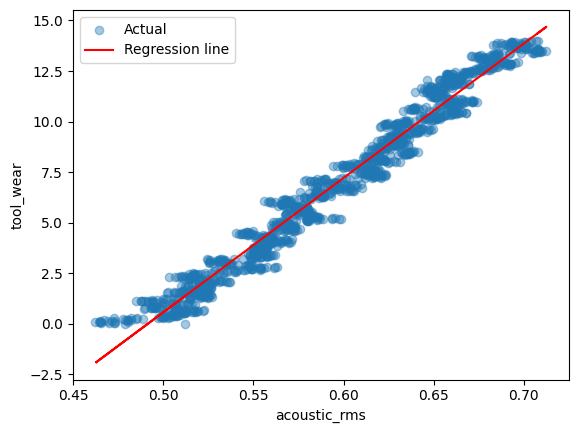

In [166]:
X = df[['mv_avg_ar']]
y = df['tool_wear']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(f"MAE: {mean_absolute_error(y, y_pred):.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")
print(f"回帰式: tool_wear = {model.coef_[0]:.4f} * acoustic_rms + {model.intercept_:.4f}")

plt.scatter(X, y, alpha=0.4, label='Actual')
plt.plot(X, y_pred, color='red', label='Regression line')
plt.xlabel('acoustic_rms')
plt.ylabel('tool_wear')
plt.legend()
plt.show()

20回分の加工データの移動平均を取ったデータセットから振動データを削除し、モデルを作成した。評価値はR^2 =0.982, MAE=0.394。

次に"acoustic_rms"のみで単回帰分析を行うと、評価値は、R^2 =0.971, MAE=0.572。

MAEの変化率は、振動データを削除すると+64.2%、"spindle_load"も削除すると+138.2%。

このことから、高精度な予測をしようとすると全てのセンサが必要なことが確認できた。

ただし、振動データと"spindle_load"を両方削除したデータセットから作成されたモデルでもR^2=0.971と非常に高く、高い予測精度を求めなければ、音響センサ(acoustic_rms)のみでも十分予測精度が高いモデルが構築可能。

まとめ

工具摩耗値の予測を高精度にしようとするなら複数の加工データと全てのセンサのデータが必要である。 


加工データの数について、求められる加工精度にもよるため一概には言えないが、データ数5以上であればR^2が0.9以上の非常に予測精度が良いモデルが作成可能。

１回の加工データからの予測ではMAEは1.8〜1.9程度で、振動センサのデータを無くしてもほとんどモデルの予測精度には影響しない。

必要なセンサについて、音響センサだけでも20回分の加工データがあれば十分に精度の良いモデルは作成可能であり、高精度が必要でなければ音響センサのみでもよい。